Sam COLLIN - 40316218
# Challenge 1

In this project, I used [**WandB.ai**](https://wandb.ai/home) to visualize efficiently my results. As it relies on optimizing and comparing different versions. I think it is a very useful and powerful to effectively assess performances and retain all the tries.
We need to start by importing it:

In [ ]:
!pip install wandb --quiet

Here we need to log in. This has to be andled for project submission.

In [ ]:
import wandb
wandb.login(key="") # My key is hidden for privacy, put yours if needed

We will first start from the baseline provided model. It is an interesting model as it is a CNN. We know that CNN are particularly well adapted for images as it captures local-dependencies. It makes it a perfect candidate to start our analysis. In case of a few-shot application as this one, we really need to ensure our model is not too large simply because we don't want to overfit. The first baseline model is named ``Net_baseline``and has the folowing architecture consisting of:

- A Conv2d layer with 3 input channels, 16 output channels, and a kernel size of 3, followed by a ReLU activation.

- A Conv2d layer with 16 input channels, 16 output channels, a kernel size of 3, and a stride of 2, followed by a ReLU activation.

- A Conv2d layer with 16 input channels, 32 output channels, and a kernel size of 3, followed by a ReLU activation.

- A Conv2d layer with 32 input channels, 32 output channels, a kernel size of 3, and a stride of 2, followed by a ReLU activation.

- A fully connected (Linear) layer mapping from 32 × 5 × 5 features to 10 output classes.


*Many other models are defined below and are depicted later in the study when needed.*

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Net_baseline(torch.nn.Module):
    def __init__(self):
        super(Net_baseline, self).__init__()
        self.layers = nn.ModuleList()

        self.layers+=[nn.Conv2d(3, 16,  kernel_size=3) ,
                      nn.ReLU(inplace=True)]
        self.layers+=[nn.Conv2d(16, 16,  kernel_size=3, stride=2),
                      nn.ReLU(inplace=True)]
        self.layers+=[nn.Conv2d(16, 32,  kernel_size=3),
                      nn.ReLU(inplace=True)]
        self.layers+=[nn.Conv2d(32, 32,  kernel_size=3, stride=2),
                      nn.ReLU(inplace=True)]
        self.fc = nn.Linear(32*5*5, 10)

    def forward(self, x):
        for i in range(len(self.layers)):
          x = self.layers[i](x)
        x = x.view(-1, 32*5*5)
        x = self.fc(x)
        return x

# Deeper Model
class Net_deep(torch.nn.Module):
    def __init__(self):
        super(Net_deep, self).__init__()
        self.layers = nn.ModuleList()

        self.layers += [nn.Conv2d(3, 16, kernel_size=3), nn.ReLU(inplace=True)]
        self.layers += [nn.Conv2d(16, 16, kernel_size=3, stride=2), nn.ReLU(inplace=True)]
        # Adding an extra layer
        self.layers += [nn.Conv2d(16, 16, kernel_size=3), nn.ReLU(inplace=True)]
        self.layers += [nn.Conv2d(16, 32, kernel_size=3), nn.ReLU(inplace=True)]
        self.layers += [nn.Conv2d(32, 32, kernel_size=3, stride=2), nn.ReLU(inplace=True)]
        self.fc = nn.Linear(32*4*4, 10)

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# Wider Model
class Net_wide(torch.nn.Module):
    def __init__(self):
        super(Net_wide, self).__init__()
        self.layers = nn.ModuleList()

        self.layers += [nn.Conv2d(3, 32, kernel_size=3), nn.ReLU(inplace=True)]
        self.layers += [nn.Conv2d(32, 32, kernel_size=3, stride=2), nn.ReLU(inplace=True)]
        self.layers += [nn.Conv2d(32, 64, kernel_size=3), nn.ReLU(inplace=True)]
        self.layers += [nn.Conv2d(64, 64, kernel_size=3, stride=2), nn.ReLU(inplace=True)]
        self.fc = nn.Linear(64*5*5, 10)  # Vérifie la taille d'entrée

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# Wider Network with Batch Normalization
class Net_wide_BatchNorm(nn.Module):
    def __init__(self):
        super(Net_wide_BatchNorm, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, stride=2)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, stride=2)
        self.bn4 = nn.BatchNorm2d(64)
        self.fc = nn.Linear(64*5*5, 10)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# Wider Network with Dropout
class Net_wide_Dropout(nn.Module):
    def __init__(self, dropout_prob=0.5):
        super(Net_wide_Dropout, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, stride=2)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, stride=2)
        self.fc = nn.Linear(64*5*5, 10)
        self.dropout = nn.Dropout(dropout_prob)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.dropout(x)
        x = F.relu(self.conv2(x))
        x = self.dropout(x)
        x = F.relu(self.conv3(x))
        x = self.dropout(x)
        x = F.relu(self.conv4(x))
        x = self.dropout(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# Wider Network with Batch Normalization and Dropout
class Net_wide_BatchNorm_Dropout(nn.Module):
    def __init__(self, dropout_prob=0.5):
        super(Net_wide_BatchNorm_Dropout, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, stride=2)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, stride=2)
        self.bn4 = nn.BatchNorm2d(64)
        self.fc = nn.Linear(64*5*5, 10)
        self.dropout = nn.Dropout(dropout_prob)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.dropout(x)
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.dropout(x)
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.dropout(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# Wider Network with Group Normalization
class Net_wide_GroupNorm(nn.Module):
    def __init__(self, num_groups=8, dropout_prob=0.5):
        super(Net_wide_GroupNorm, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3)
        self.gn1 = nn.GroupNorm(num_groups=num_groups, num_channels=32)

        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, stride=2)
        self.gn2 = nn.GroupNorm(num_groups=num_groups, num_channels=32)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3)
        self.gn3 = nn.GroupNorm(num_groups=num_groups, num_channels=64)

        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, stride=2)
        self.gn4 = nn.GroupNorm(num_groups=num_groups, num_channels=64)

        self.fc = nn.Linear(64 * 5 * 5, 10)

    def forward(self, x):
        x = F.relu(self.gn1(self.conv1(x)))
        x = F.relu(self.gn2(self.conv2(x)))
        x = F.relu(self.gn3(self.conv3(x)))
        x = F.relu(self.gn4(self.conv4(x)))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# Wider Network with Group Normalization
class Net_wide_GroupNorm_Dropout(nn.Module):
    def __init__(self, num_groups=8, dropout_prob=0.5):
        super(Net_wide_GroupNorm_Dropout, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3)
        self.gn1 = nn.GroupNorm(num_groups=num_groups, num_channels=32)

        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, stride=2)
        self.gn2 = nn.GroupNorm(num_groups=num_groups, num_channels=32)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3)
        self.gn3 = nn.GroupNorm(num_groups=num_groups, num_channels=64)

        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, stride=2)
        self.gn4 = nn.GroupNorm(num_groups=num_groups, num_channels=64)

        self.fc = nn.Linear(64 * 5 * 5, 10)
        self.dropout = nn.Dropout(dropout_prob)

    def forward(self, x):
        x = F.relu(self.gn1(self.conv1(x)))
        x = self.dropout(x)
        x = F.relu(self.gn2(self.conv2(x)))
        x = self.dropout(x)
        x = F.relu(self.gn3(self.conv3(x)))
        x = self.dropout(x)
        x = F.relu(self.gn4(self.conv4(x)))
        x = self.dropout(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

The training and test functions are the following:

*(Note1: Note that the loss has been change in the training function to ensure consistency with the test and have an average loss instead of the last batch loss.)*

*(Note2: Note that I added a line ``wandb.log`` at the end of each function. It passes the metrics like train&test loss to the wandb framework to monitor them later through panels.)*

In [ ]:
def train(model, device, train_loader, optimizer, epoch, display=True):
    model.train()
    running_loss = 0.
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.cross_entropy(output, target)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Slight modif to the loss to have the mean over all the batches instead of the last one
    avg_loss = running_loss / len(train_loader)

    if display:
      print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
          epoch, batch_idx * len(data), len(train_loader.dataset),
          100. * batch_idx / len(train_loader), avg_loss))
    wandb.log({"train_loss": avg_loss, "epoch": epoch})


def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.cross_entropy(output, target, size_average=False).item() # sum up batch loss
            pred = output.max(1, keepdim=True)[1] # get the index of the max log-probability
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)
    accuracy = 100. * correct / len(test_loader.dataset)
    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        accuracy))
    wandb.log({"test_loss": test_loss, "test_accuracy": accuracy})
    return accuracy

In the following cell, data is imported and transformed. Regarding the validation set, only normalization is applied to ensure compatibility with training. Regarding the training set 5 augmentation are proposed, We'll later analyze the results and see if one is better than another.

*(Note: Here ``transform_train_0`` means no data augmentation)*

In [ ]:
from numpy.random import RandomState
import numpy as np
import torch.optim as optim
from torch.utils.data import Subset

from torchvision import datasets, transforms
normalize = transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))

use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

transform_val = transforms.Compose([transforms.ToTensor(), normalize]) #careful to keep this one same
#We need two copies of this due to weird dataset api
cifar_data_val = datasets.CIFAR10(root='.',train=True, transform=transform_val, download=True)


## Data augmentation ##

# Baseline (no augmentation)
transform_train_0 = transforms.Compose([transforms.ToTensor(), normalize])
cifar_data_0 = datasets.CIFAR10(root='.',train=True, transform=transform_train_0, download=True)

# Cropping + Flip
transform_train_1 = transforms.Compose([
    transforms.RandomCrop(32, padding=4),    # recadrage aléatoire avec remplissage
    transforms.RandomHorizontalFlip(),       # rdm horizontal flip
    transforms.ToTensor(),
    normalize
])

# Rotation + Color
transform_train_2 = transforms.Compose([
    transforms.RandomRotation(15),  # Random rotation in the range [-15, 15] degrees
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    normalize
])

# Random Affine
transform_train_3 = transforms.Compose([
    transforms.RandomAffine(
        degrees=10,              # Rotation in a narrower range
        translate=(0.1, 0.1),    # Horizontal and vertical translation (10% of the image)
        scale=(0.9, 1.1),        # Scale varying between 90% and 110%
        shear=10               # Maximum shear of 10 degrees
    ),
    transforms.ToTensor(),
    normalize
])

transform_train_4 = transforms.Compose([
    transforms.RandomHorizontalFlip(),  # You can keep a flip as a precaution
    transforms.ToTensor(),
    normalize,
    transforms.RandomErasing(
        p=0.5,                  # Probability of deletion
        scale=(0.02, 0.33)      # Size of deleted area as a proportion of the image
    )
])

transform_train_5 = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.GaussianBlur(kernel_size=3),  # Applying Gaussian blur with a 3x3 kernel
    transforms.ToTensor(),
    normalize
])


transform_dict = {
    0: transform_train_0,
    1: transform_train_1,
    2: transform_train_2,
    3: transform_train_3,
    4: transform_train_4,
    5: transform_train_5
}

100%|██████████| 170M/170M [00:04<00:00, 39.2MB/s]


Finally, this is our main function. Before running it, we have to make sure that the runs are well configured.

The goal here is to train a certain configuration for a given number of seeds to average the results as the variance might be very high for few-shots applications.

The configuration instantiated by ``wandb.init()`` allows to define all the hyperparameters that we want for our model but also any specific variable that could be needeed to describe or differentiate a run from another. We can give a name, and associate with a certain group or tags. By entering this information correctly, we can easily manage the results in the graphical interface and group them as we want to vusalize differences.

The steps are te following:

  1. Loop over each seed
  2. Define the configuration (The same will remain for all the seed except the name of the run)
  3. Apply data augmentation if needed and pick random samples to create the subsets of 25 samples per class for training and 200 for test.
  4. Instantiate the model and the optimizer
  5. Train and test the actual configuration
  6. Display the final mean accuracy over all seeds and compute the std

### Main

In [ ]:
accs = []
n_seeds = 12

for seed in range(1, n_seeds+1):

  # Separate the runs in wandb to compare easily:
  wandb.init(
        project="Challenge1_DL_v6",
        name=f"Run_seed_{seed}",
        group="Baseline_OPTIMIZED_REGULARIZED",
        tags=["Baseline_OPTIMIZED_REGULARIZED"],
        config={
            "seed": seed,
            "epochs": 100,
            "batch_size": 32,
            "lr": 0.01,
            "momentum": 0.8,
            "weight_decay": 0.001,
            "model": "Net_complex",
            "dropout_prob": 0.2,
            "data_augmentation": 1   # zero means no augmentation
        },
        reinit=True
    )

  prng = RandomState(seed)
  random_permute = prng.permutation(np.arange(0, 1000))
  classes =  prng.permutation(np.arange(0,10))

  cifar_data = datasets.CIFAR10(
      root='.',
      train=True,
      transform=transform_dict[wandb.config.data_augmentation],
      download=True
      )

  indx_train = np.concatenate([np.where(np.array(cifar_data.targets) == classe)[0][random_permute[0:25]] for classe in classes[0:2]])
  indx_val = np.concatenate([np.where(np.array(cifar_data.targets) == classe)[0][random_permute[25:225]] for classe in classes[0:2]])

  train_data = Subset(cifar_data, indx_train)
  val_data = Subset(cifar_data_val, indx_val)

  print('Num Samples For Training %d Num Samples For Val %d'%(train_data.indices.shape[0],val_data.indices.shape[0]))

  train_loader = torch.utils.data.DataLoader(train_data,
                                             batch_size=wandb.config.batch_size,
                                             shuffle=True)

  val_loader = torch.utils.data.DataLoader(val_data,
                                           batch_size=wandb.config.batch_size,
                                           shuffle=False)

  model = Net_wide_BatchNorm_Dropout(dropout_prob=wandb.config.dropout_prob)
  model.to(device)
  optimizer = torch.optim.SGD(model.parameters(),lr=wandb.config.lr, momentum=wandb.config.momentum,
                              weight_decay=wandb.config.weight_decay)

  for epoch in range(wandb.config.epochs):
    train(model, device, train_loader, optimizer, epoch, display=epoch%5==0)

  accs.append(test(model, device, val_loader))
  wandb.finish()

accs = np.array(accs)
print(f'Acc over {n_seeds} instances: %.2f +- %.2f'%(accs.mean(),accs.std()))

Num Samples For Training 50 Num Samples For Val 400
Train Epoch: 0 [18/50 (50%)]	Loss: 2.268318
Train Epoch: 5 [18/50 (50%)]	Loss: 0.777241
Train Epoch: 10 [18/50 (50%)]	Loss: 0.795127
Train Epoch: 15 [18/50 (50%)]	Loss: 0.746066
Train Epoch: 20 [18/50 (50%)]	Loss: 0.741916
Train Epoch: 25 [18/50 (50%)]	Loss: 0.714411
Train Epoch: 30 [18/50 (50%)]	Loss: 0.675044
Train Epoch: 35 [18/50 (50%)]	Loss: 0.668544
Train Epoch: 40 [18/50 (50%)]	Loss: 0.704982
Train Epoch: 45 [18/50 (50%)]	Loss: 0.656939
Train Epoch: 50 [18/50 (50%)]	Loss: 0.734395
Train Epoch: 55 [18/50 (50%)]	Loss: 0.697174
Train Epoch: 60 [18/50 (50%)]	Loss: 0.674603
Train Epoch: 65 [18/50 (50%)]	Loss: 0.714187
Train Epoch: 70 [18/50 (50%)]	Loss: 0.688684
Train Epoch: 75 [18/50 (50%)]	Loss: 0.619251
Train Epoch: 80 [18/50 (50%)]	Loss: 0.678015
Train Epoch: 85 [18/50 (50%)]	Loss: 0.684245
Train Epoch: 90 [18/50 (50%)]	Loss: 0.713573
Train Epoch: 95 [18/50 (50%)]	Loss: 0.676528

Test set: Average loss: 0.8845, Accuracy: 201/400

epoch,▁▁▂▂▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇█
test_accuracy,▁
test_loss,▁
train_loss,█▅▄▅▅▄▃▃▄▃▄▅▄▄▃▄▂▄▃▄▄▃▃▃▃▃▄▃▄▃▃▄▃▂▃▁▂▄▃▂
epoch,99
test_accuracy,50.25
test_loss,0.88454
train_loss,0.56881


Num Samples For Training 50 Num Samples For Val 400
Train Epoch: 0 [18/50 (50%)]	Loss: 2.028235
Train Epoch: 5 [18/50 (50%)]	Loss: 0.741217
Train Epoch: 10 [18/50 (50%)]	Loss: 0.693843
Train Epoch: 15 [18/50 (50%)]	Loss: 0.629378
Train Epoch: 20 [18/50 (50%)]	Loss: 0.666555
Train Epoch: 25 [18/50 (50%)]	Loss: 0.638812
Train Epoch: 30 [18/50 (50%)]	Loss: 0.658523
Train Epoch: 35 [18/50 (50%)]	Loss: 0.657640
Train Epoch: 40 [18/50 (50%)]	Loss: 0.669726
Train Epoch: 45 [18/50 (50%)]	Loss: 0.667895
Train Epoch: 50 [18/50 (50%)]	Loss: 0.587389
Train Epoch: 55 [18/50 (50%)]	Loss: 0.661732
Train Epoch: 60 [18/50 (50%)]	Loss: 0.553501
Train Epoch: 65 [18/50 (50%)]	Loss: 0.578710
Train Epoch: 70 [18/50 (50%)]	Loss: 0.570278
Train Epoch: 75 [18/50 (50%)]	Loss: 0.584055
Train Epoch: 80 [18/50 (50%)]	Loss: 0.588404
Train Epoch: 85 [18/50 (50%)]	Loss: 0.559145
Train Epoch: 90 [18/50 (50%)]	Loss: 0.692294
Train Epoch: 95 [18/50 (50%)]	Loss: 0.718696

Test set: Average loss: 0.7542, Accuracy: 245/400

epoch,▁▁▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇███
test_accuracy,▁
test_loss,▁
train_loss,█▄▄▄▄▃▃▃▃▃▃▃▂▃▃▃▃▂▃▃▃▄▂▃▂▂▃▃▃▂▂▂▂▃▂▂▂▂▁▁
epoch,99
test_accuracy,61.25
test_loss,0.75425
train_loss,0.53421


Num Samples For Training 50 Num Samples For Val 400
Train Epoch: 0 [18/50 (50%)]	Loss: 2.368080
Train Epoch: 5 [18/50 (50%)]	Loss: 0.670043
Train Epoch: 10 [18/50 (50%)]	Loss: 0.655921
Train Epoch: 15 [18/50 (50%)]	Loss: 0.511733
Train Epoch: 20 [18/50 (50%)]	Loss: 0.496368
Train Epoch: 25 [18/50 (50%)]	Loss: 0.574241
Train Epoch: 30 [18/50 (50%)]	Loss: 0.519674
Train Epoch: 35 [18/50 (50%)]	Loss: 0.426108
Train Epoch: 40 [18/50 (50%)]	Loss: 0.358175
Train Epoch: 45 [18/50 (50%)]	Loss: 0.434155
Train Epoch: 50 [18/50 (50%)]	Loss: 0.435075
Train Epoch: 55 [18/50 (50%)]	Loss: 0.422146
Train Epoch: 60 [18/50 (50%)]	Loss: 0.414053
Train Epoch: 65 [18/50 (50%)]	Loss: 0.367344
Train Epoch: 70 [18/50 (50%)]	Loss: 0.207547
Train Epoch: 75 [18/50 (50%)]	Loss: 0.384687
Train Epoch: 80 [18/50 (50%)]	Loss: 0.431445
Train Epoch: 85 [18/50 (50%)]	Loss: 0.214131
Train Epoch: 90 [18/50 (50%)]	Loss: 0.226294
Train Epoch: 95 [18/50 (50%)]	Loss: 0.238303

Test set: Average loss: 0.6873, Accuracy: 301/400

...

Num Samples For Training 50 Num Samples For Val 400
Train Epoch: 0 [18/50 (50%)]	Loss: 2.614937
Train Epoch: 5 [18/50 (50%)]	Loss: 0.583024
Train Epoch: 10 [18/50 (50%)]	Loss: 0.550300
Train Epoch: 15 [18/50 (50%)]	Loss: 0.507198
Train Epoch: 20 [18/50 (50%)]	Loss: 0.454155
Train Epoch: 25 [18/50 (50%)]	Loss: 0.416526
Train Epoch: 30 [18/50 (50%)]	Loss: 0.431578
Train Epoch: 35 [18/50 (50%)]	Loss: 0.340473
Train Epoch: 40 [18/50 (50%)]	Loss: 0.421930
Train Epoch: 45 [18/50 (50%)]	Loss: 0.384857
Train Epoch: 50 [18/50 (50%)]	Loss: 0.319399
Train Epoch: 55 [18/50 (50%)]	Loss: 0.528599
Train Epoch: 60 [18/50 (50%)]	Loss: 0.398733
Train Epoch: 65 [18/50 (50%)]	Loss: 0.390269
Train Epoch: 70 [18/50 (50%)]	Loss: 0.448011
Train Epoch: 75 [18/50 (50%)]	Loss: 0.460518
Train Epoch: 80 [18/50 (50%)]	Loss: 0.368098
Train Epoch: 85 [18/50 (50%)]	Loss: 0.429326
Train Epoch: 90 [18/50 (50%)]	Loss: 0.321836
Train Epoch: 95 [18/50 (50%)]	Loss: 0.365793

Test set: Average loss: 0.8608, Accuracy: 284/400

epoch,▁▁▁▁▁▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▆▆▆▇▇▇▇▇▇▇▇███
test_accuracy,▁
test_loss,▁
train_loss,█▄▃▂▂▂▂▂▂▂▂▁▂▁▂▂▂▁▁▁▁▁▂▁▁▁▁▂▁▁▁▁▂▁▁▁▁▁▁▁
epoch,99
test_accuracy,71
test_loss,0.86079
train_loss,0.37009


Num Samples For Training 50 Num Samples For Val 400
Train Epoch: 0 [18/50 (50%)]	Loss: 2.368069
Train Epoch: 5 [18/50 (50%)]	Loss: 0.733769
Train Epoch: 10 [18/50 (50%)]	Loss: 0.592514
Train Epoch: 15 [18/50 (50%)]	Loss: 0.637419
Train Epoch: 20 [18/50 (50%)]	Loss: 0.596658
Train Epoch: 25 [18/50 (50%)]	Loss: 0.542895
Train Epoch: 30 [18/50 (50%)]	Loss: 0.552144
Train Epoch: 35 [18/50 (50%)]	Loss: 0.649197
Train Epoch: 40 [18/50 (50%)]	Loss: 0.507942
Train Epoch: 45 [18/50 (50%)]	Loss: 0.429072
Train Epoch: 50 [18/50 (50%)]	Loss: 0.484029
Train Epoch: 55 [18/50 (50%)]	Loss: 0.388799
Train Epoch: 60 [18/50 (50%)]	Loss: 0.449357
Train Epoch: 65 [18/50 (50%)]	Loss: 0.535270
Train Epoch: 70 [18/50 (50%)]	Loss: 0.418495
Train Epoch: 75 [18/50 (50%)]	Loss: 0.473134
Train Epoch: 80 [18/50 (50%)]	Loss: 0.393785
Train Epoch: 85 [18/50 (50%)]	Loss: 0.405526
Train Epoch: 90 [18/50 (50%)]	Loss: 0.365000
Train Epoch: 95 [18/50 (50%)]	Loss: 0.357803

Test set: Average loss: 0.8967, Accuracy: 270/400

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇█████
test_accuracy,▁
test_loss,▁
train_loss,█▄▃▂▂▂▂▂▁▂▂▂▂▂▂▂▁▁▂▁▁▂▂▁▁▂▁▂▁▁▁▁▁▂▁▁▁▁▁▁
epoch,99
test_accuracy,67.5
test_loss,0.89666
train_loss,0.26508


Acc over 12 instances: 67.04 +- 8.18


# Results Analysis for challenge 1
## Baseline

Thanks to wandb.ai, we can now visualize our results. The first step is to run our **baseline** for twelve different seeds.
To recall, our baseline is:
- "epochs": 100
- "batch_size": 128
- "lr": 0.01
- "momentum": 0.9
- "weight_decay": 0.0005
- "model": "Net_baseline"
- "data_augmentation": 0    # zero means no augmentation

The following results are obtained:

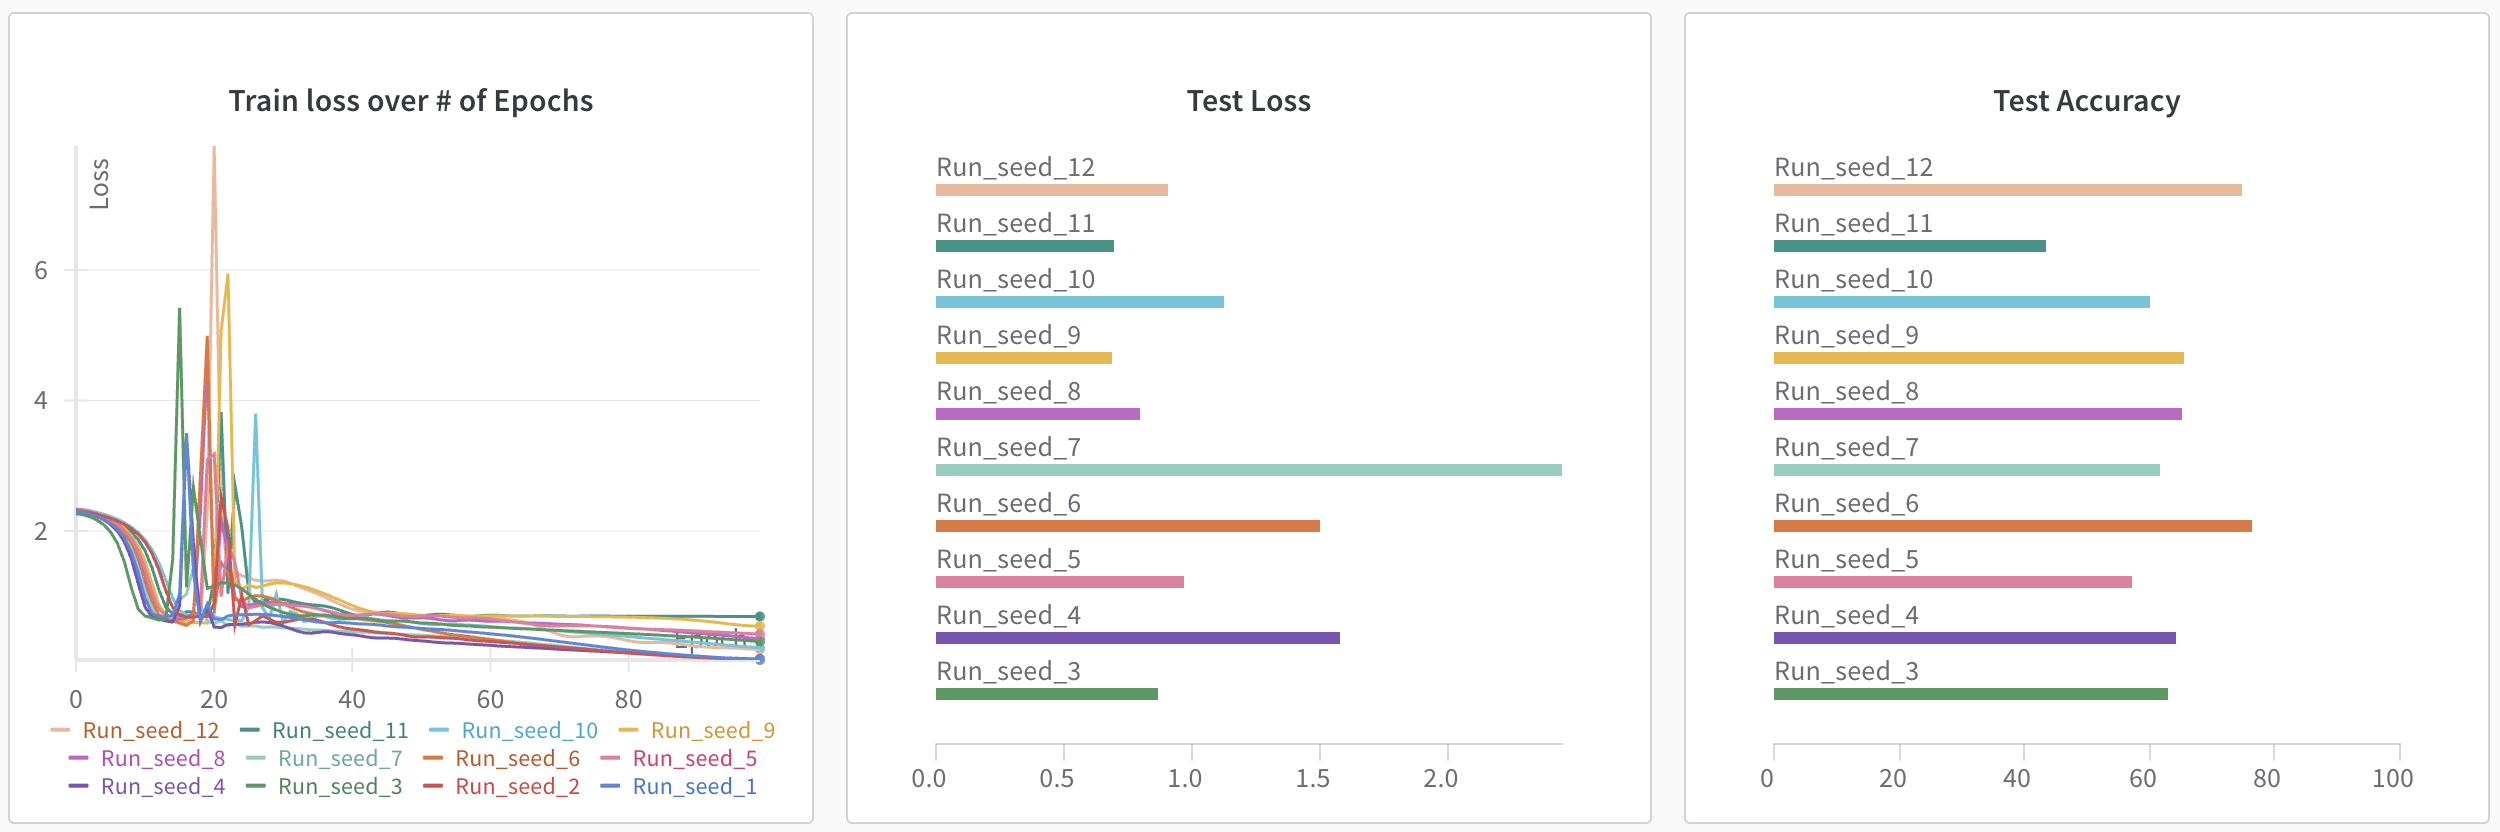

Here, one can see each seed of the configuration runned. For the rest of the study and to enforce the analysis we will work with the mean of these 12 seeds per config. So, once grouped the baseline configuration is represented by the following metrics:

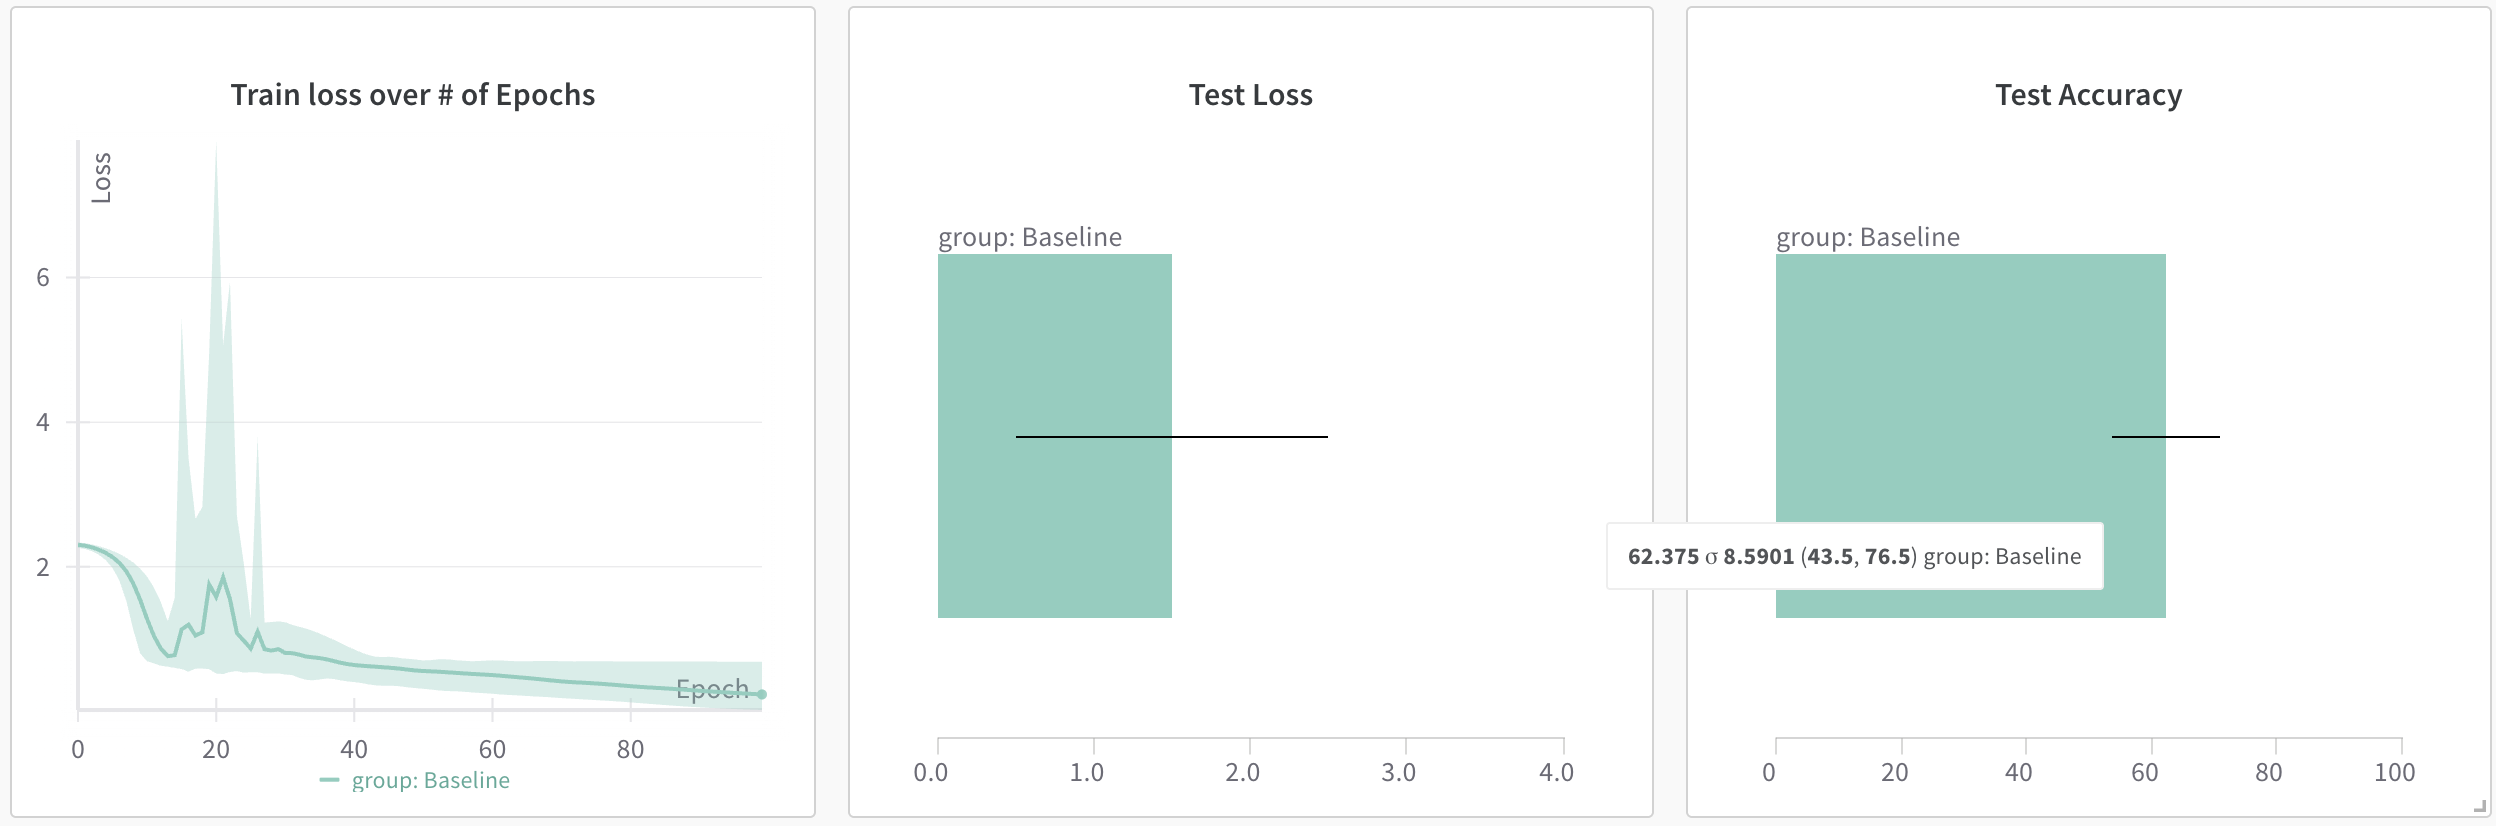

The baseline has a final training loss of 0.23 and a test loss of 1.5

The averaged test accuracy for our baseline is **62.38** with a standard deviation σ of 8.6

## Hyperparameter tuning
To see if our model can improve, before using heavy techniques we can study the role of the hparams and see what's their role on the model.


### Learning rate
Let's start by the learning rate used to optimize with SGD.
Different values have been tested such as {0.001, 0.005, 0.01 (baseline), and 0.05}.
Their result comparison is the following:



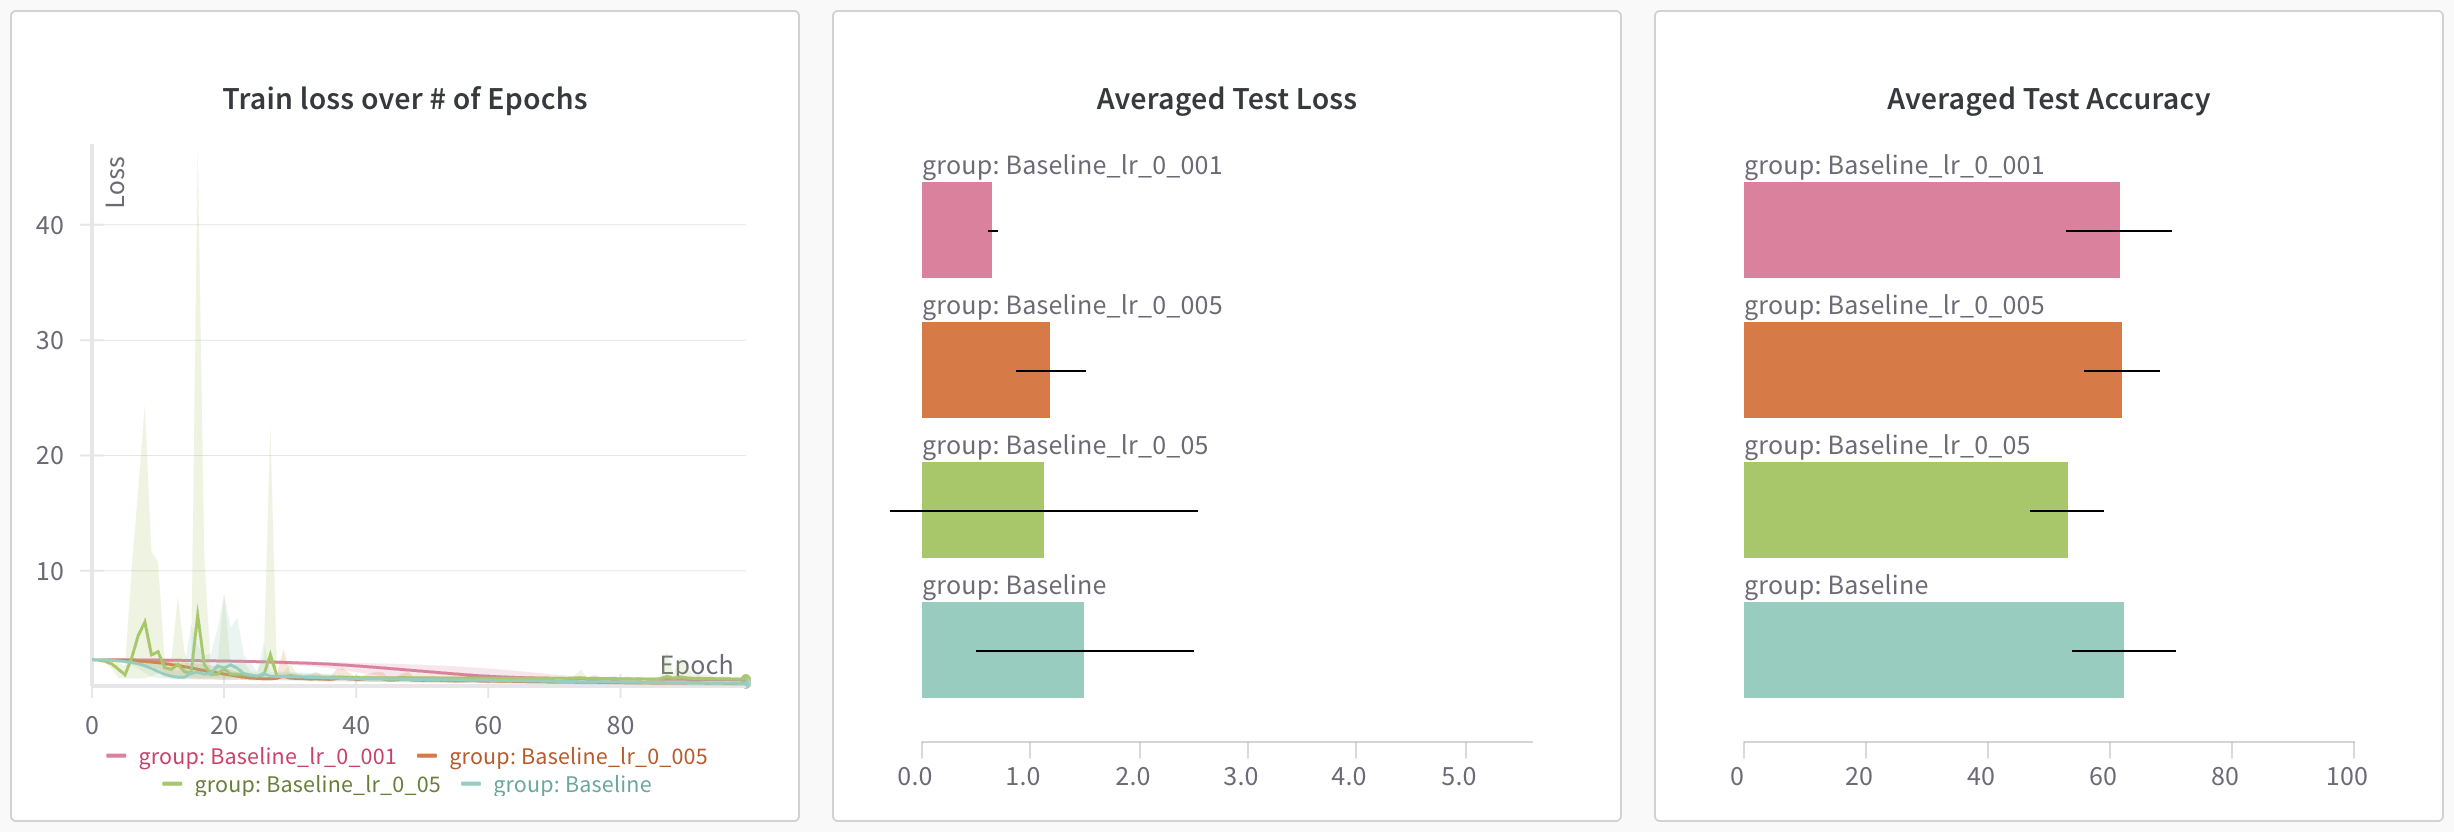

One can see that, despite 0.05, the result are almost the same in tems of accuracy. To continue simply, **we'll stick with lr=0.01** as in the baseline.

## Batch_size

Let's try different batc size to see what's best:

Tested values are {16, 32, 64, 128 (baseline), 256}.

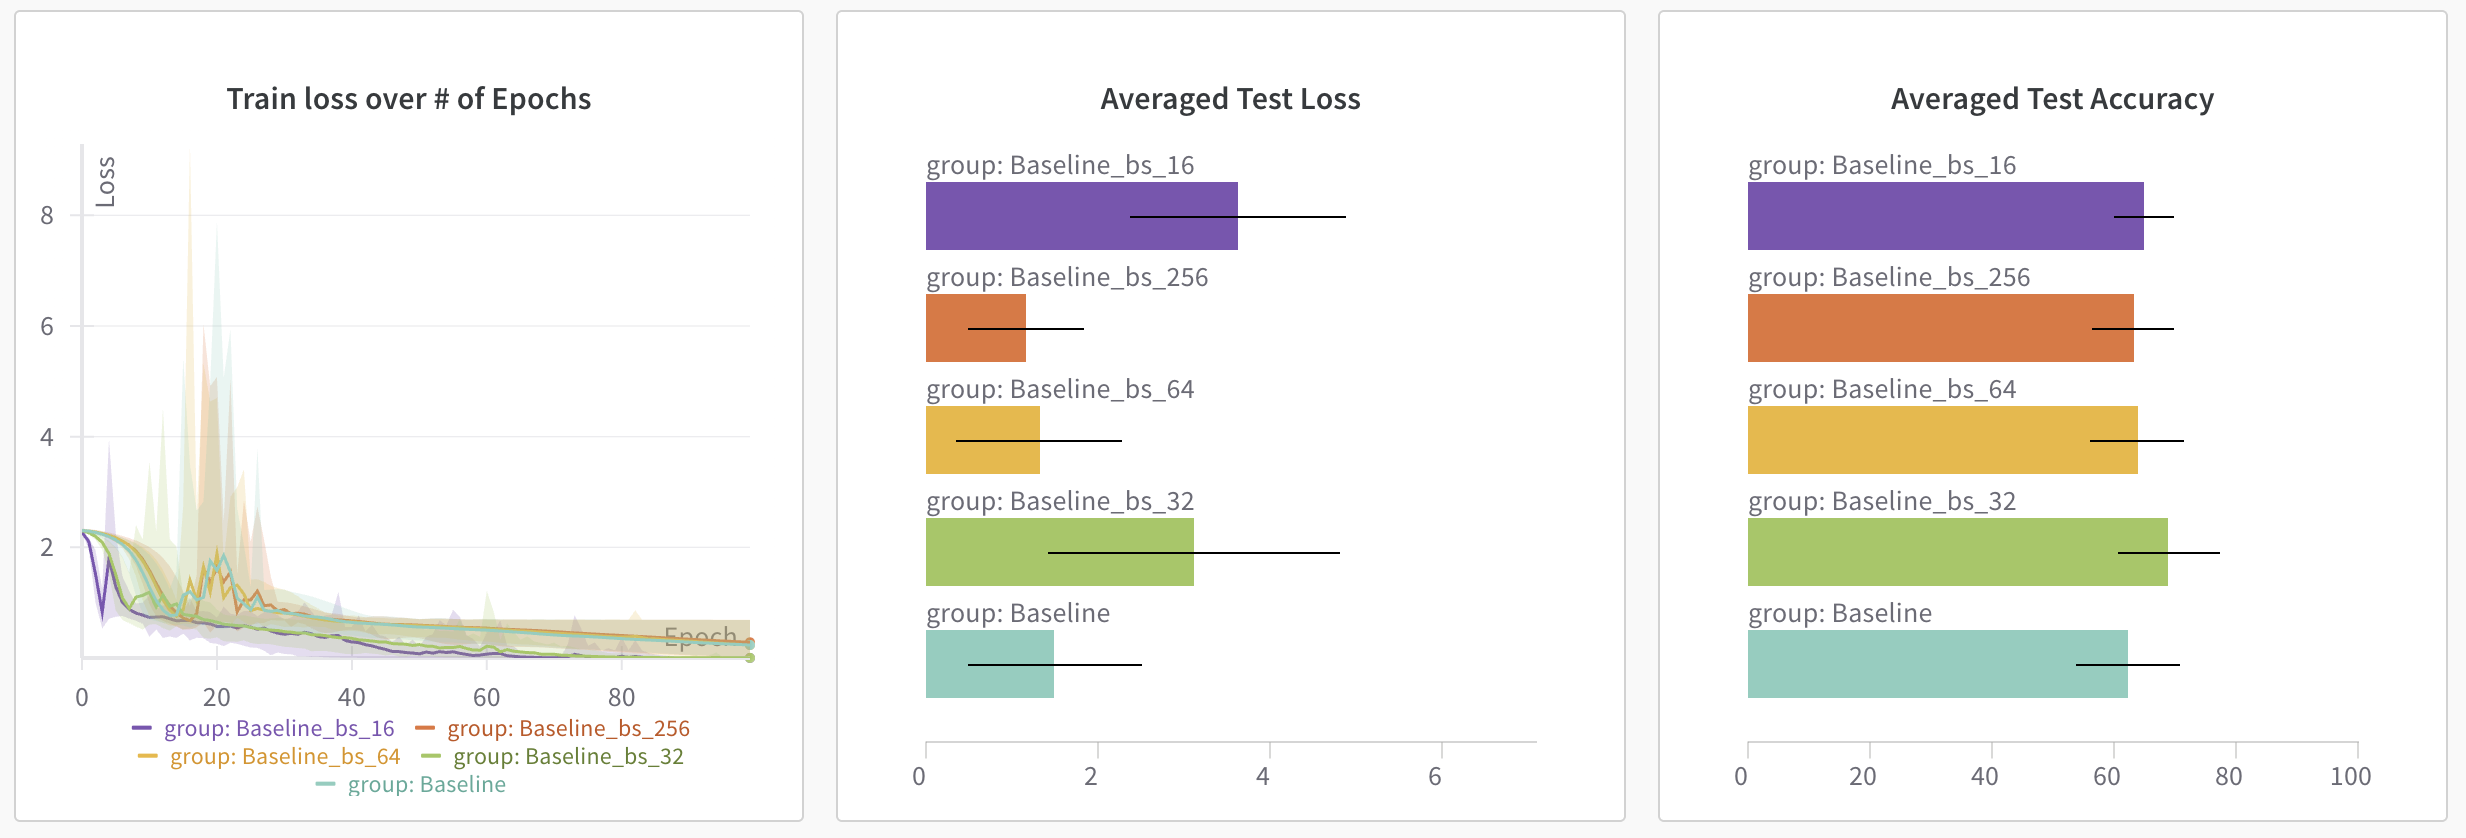

These results may seem counter-intuitive. Indeed, the best accuracy seems to have a higher loss. A larger batch size provides a more stable estimator of the gradient, which can result in more consistent convergence in terms of loss, but sometimes less generalisation, or vice versa. A smaller batch size introduces more noise into the updating of the weights (stochasticity), which can encourage better exploration of the parameter space.

It might need further exploration but for now, **we'll retain 32 for the optimal model**. Small batch sie for few shot is often a good idea.

## Momentum
The tested values for the momentum are : {0,7,0.8, 0.85, 0.9 (baseline), 0.95}

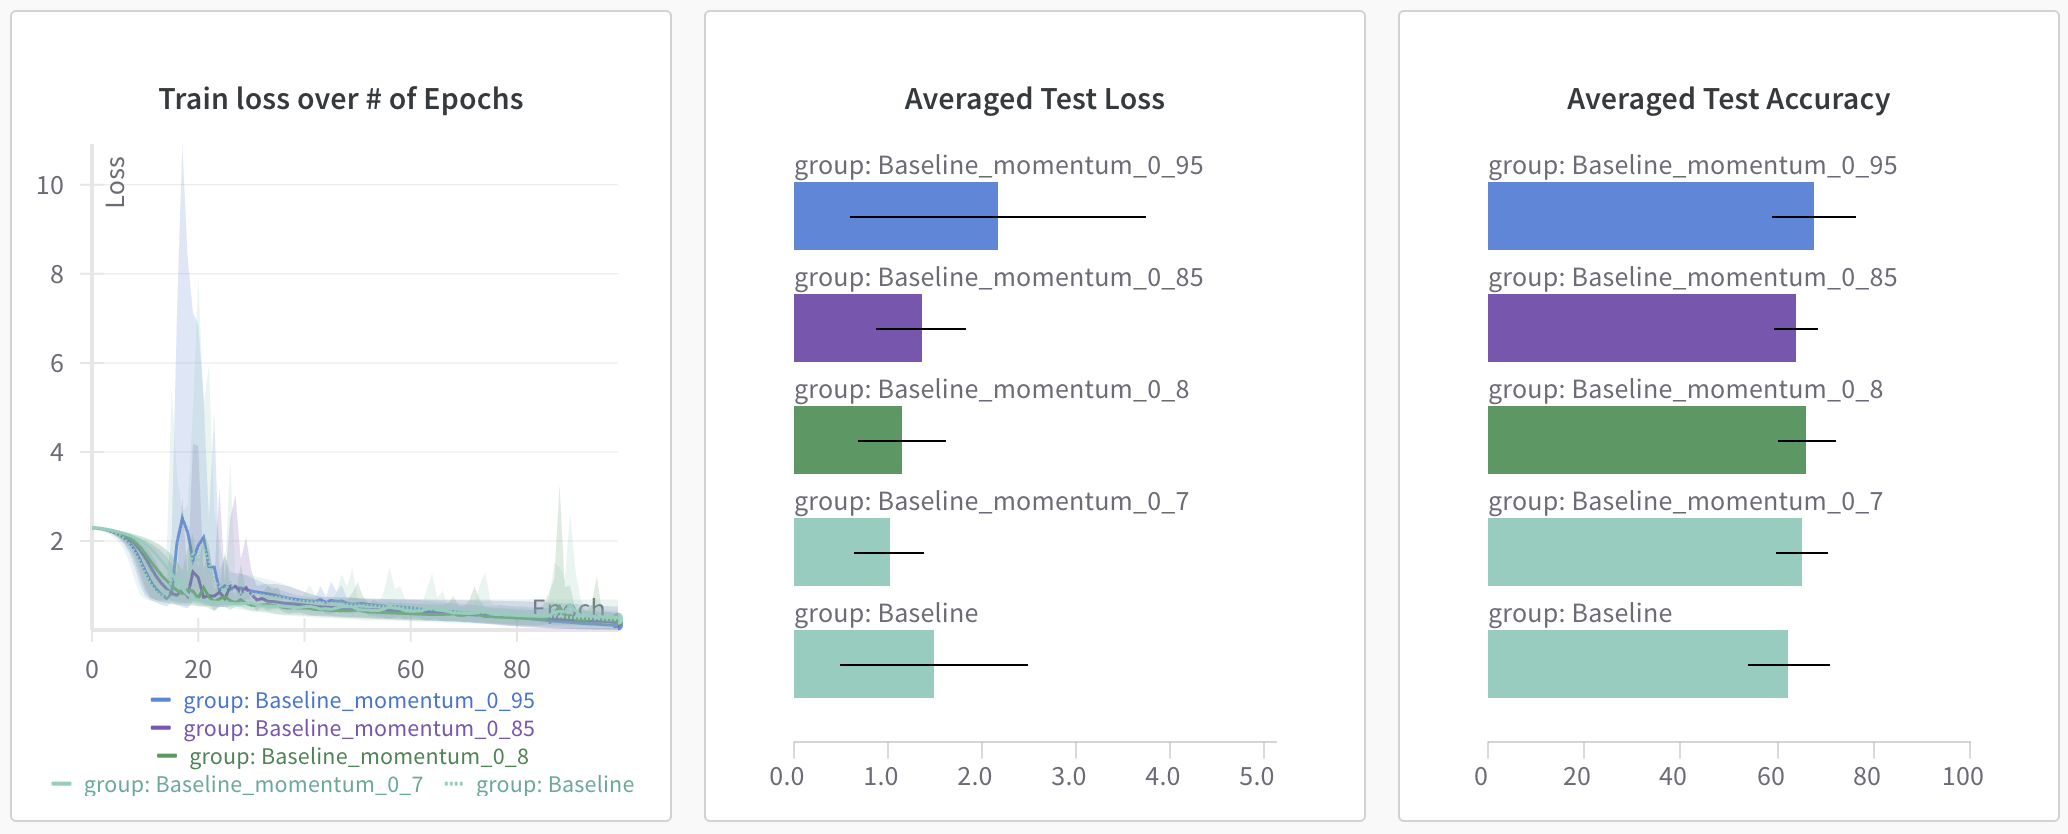

At first sight, momentum 0.95 has the best results. However when we look closer at the test loss and the accuracy's standard deviation, one can see that 0.8 might look more consistent and promising. **We will use 0.8 for the optimized model.**

## Weight decay
The tested values are : {0.0001, 0.0005 (baseline), 0.001}


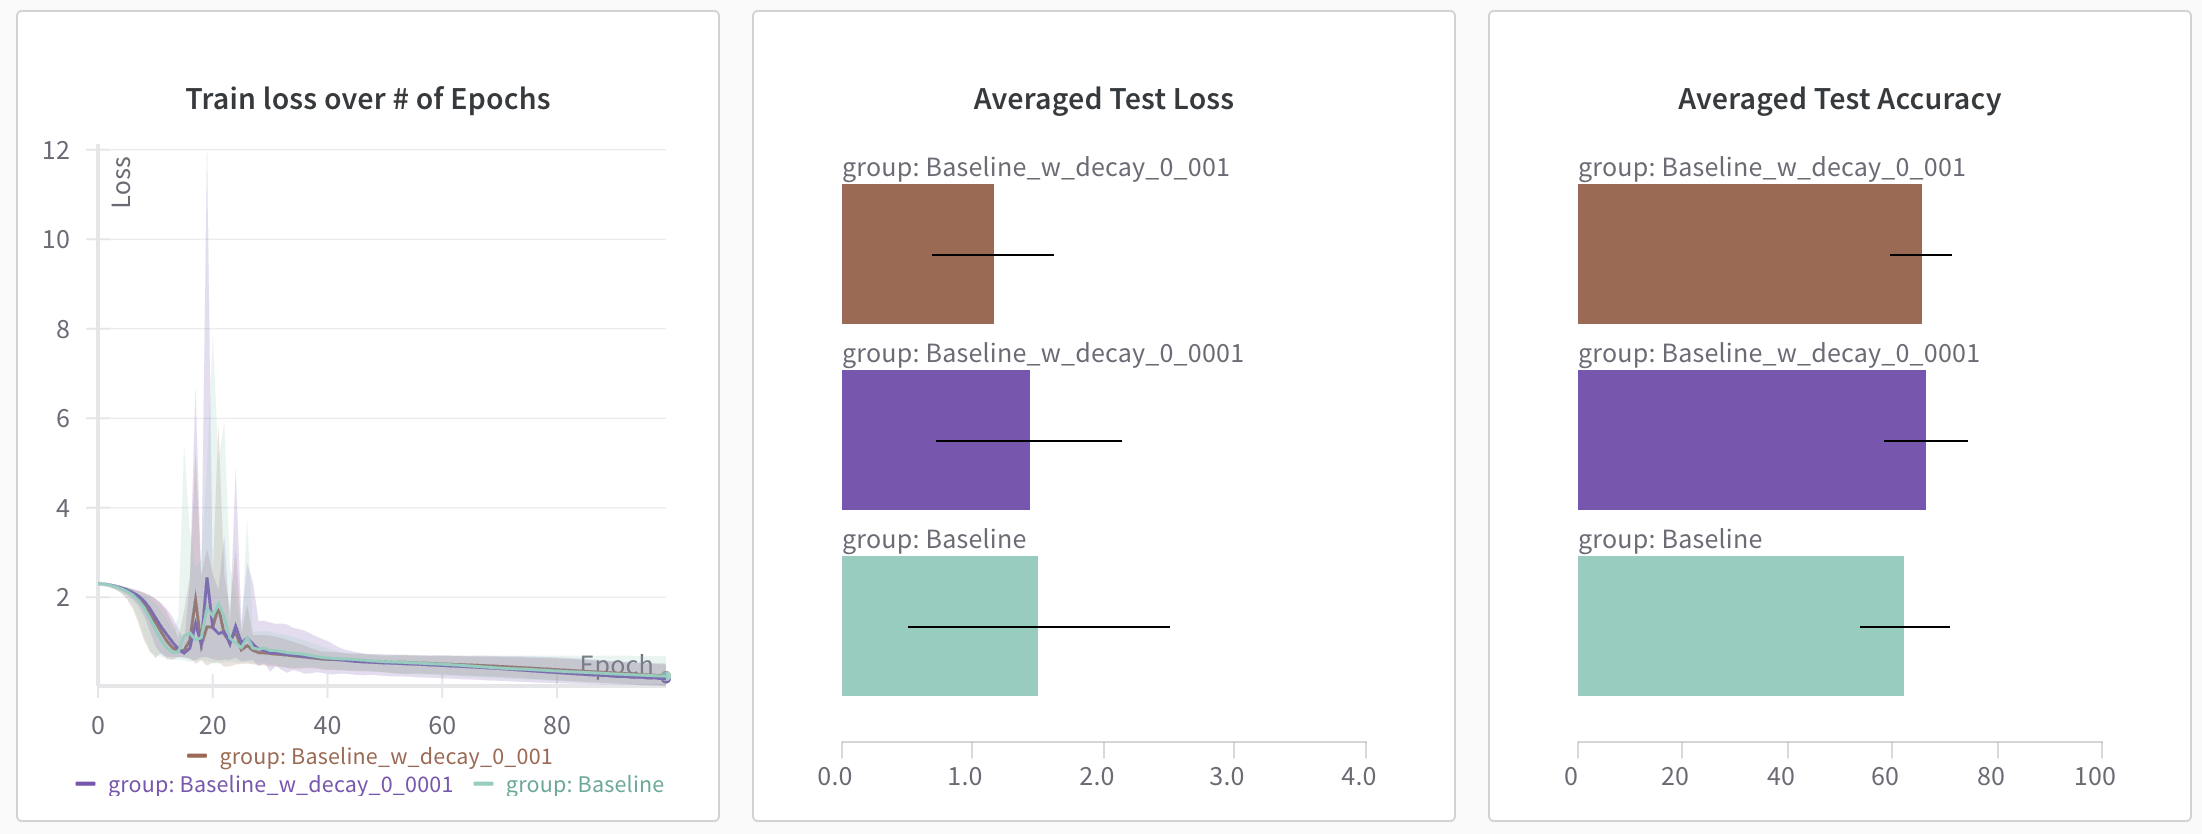

The results are similar, regarding the std, it seems that 0.001 looks a bit more consistent.

## Architecture
It is now time to vary the architecture.

The first variation Baseline_deep is a deeper network. From the original model, we added 1 layer :

- A Conv2d layer with 16 input channels, 16 output channels, a kernel size of 3, and a stride of 2, followed by a ReLU activation.

The second variation Baseline_wide is a wider network. From the original model, we added more neurons :

- The number of channels has been multiplied by two

*(Note: Full architectures are available above)*


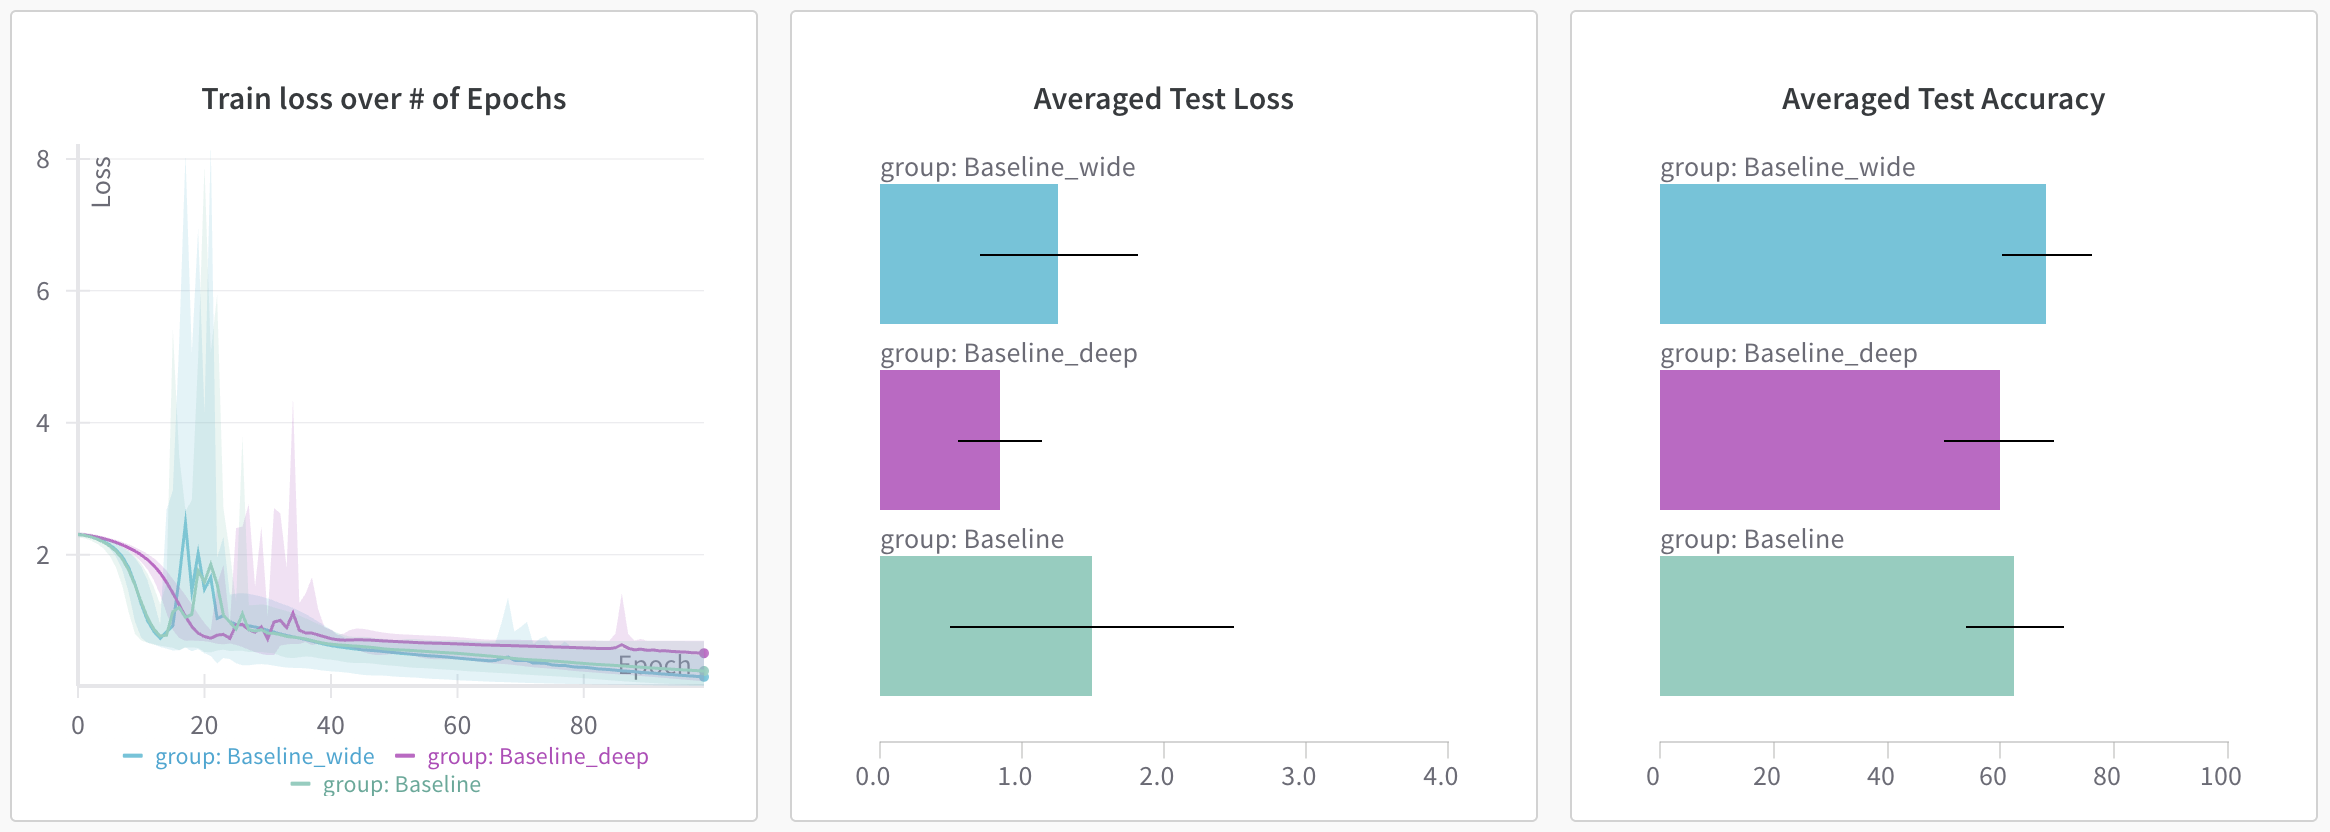

In a few-shot scenario with very limited data,  deeper architecture tends to increase the risk of overfitting and training instability due to its additional layers and parameters, it makes it more likely to memorize the few available examples rather than learn robust features. On the other hand, widening the network—by increasing the number of channels in each layer—enhances its representational capacity without substantially increasing its depth, enabling it to capture richer features and generalize better while still maintaining a relatively stable training process.

For now, **the wide architecture will be retained**.

## Data augmentation

Finally, we introduce data augmentation. In a few-shot context, it can really make a huge difference. Data is modified to be a bit noisier and the model should be more robust in the end. The techniques are the following :

 - **Data augmentation 0 (baseline)** : uses the original images with only basic normalization as a baseline.

 - **Data augmentation 1** : applies random cropping with padding and random horizontal flipping, introducing variations in object position and mirror invariance.

 - **Data augmentation 2** : combines random rotation (up to 15°) with color jitter (adjusting brightness, contrast, saturation, and hue) to simulate changes in viewpoint and lighting conditions.

 - **Data augmentation 3** : employs random affine transformations—including slight rotations, translations, scaling, and shearing—to mimic geometric distortions.

 - **Data augmentation 4** : involves a random horizontal flip followed by random erasing, which occludes a random portion of the image to simulate noise or partial occlusion.

 - **Data augmentation 5** : applies a random horizontal flip coupled with Gaussian blur (using a 3×3 kernel) to emulate slight out-of-focus effects.

 All these transformations are chosen randomly. The goal is to see the effect of each perturbation and choose the most promising.

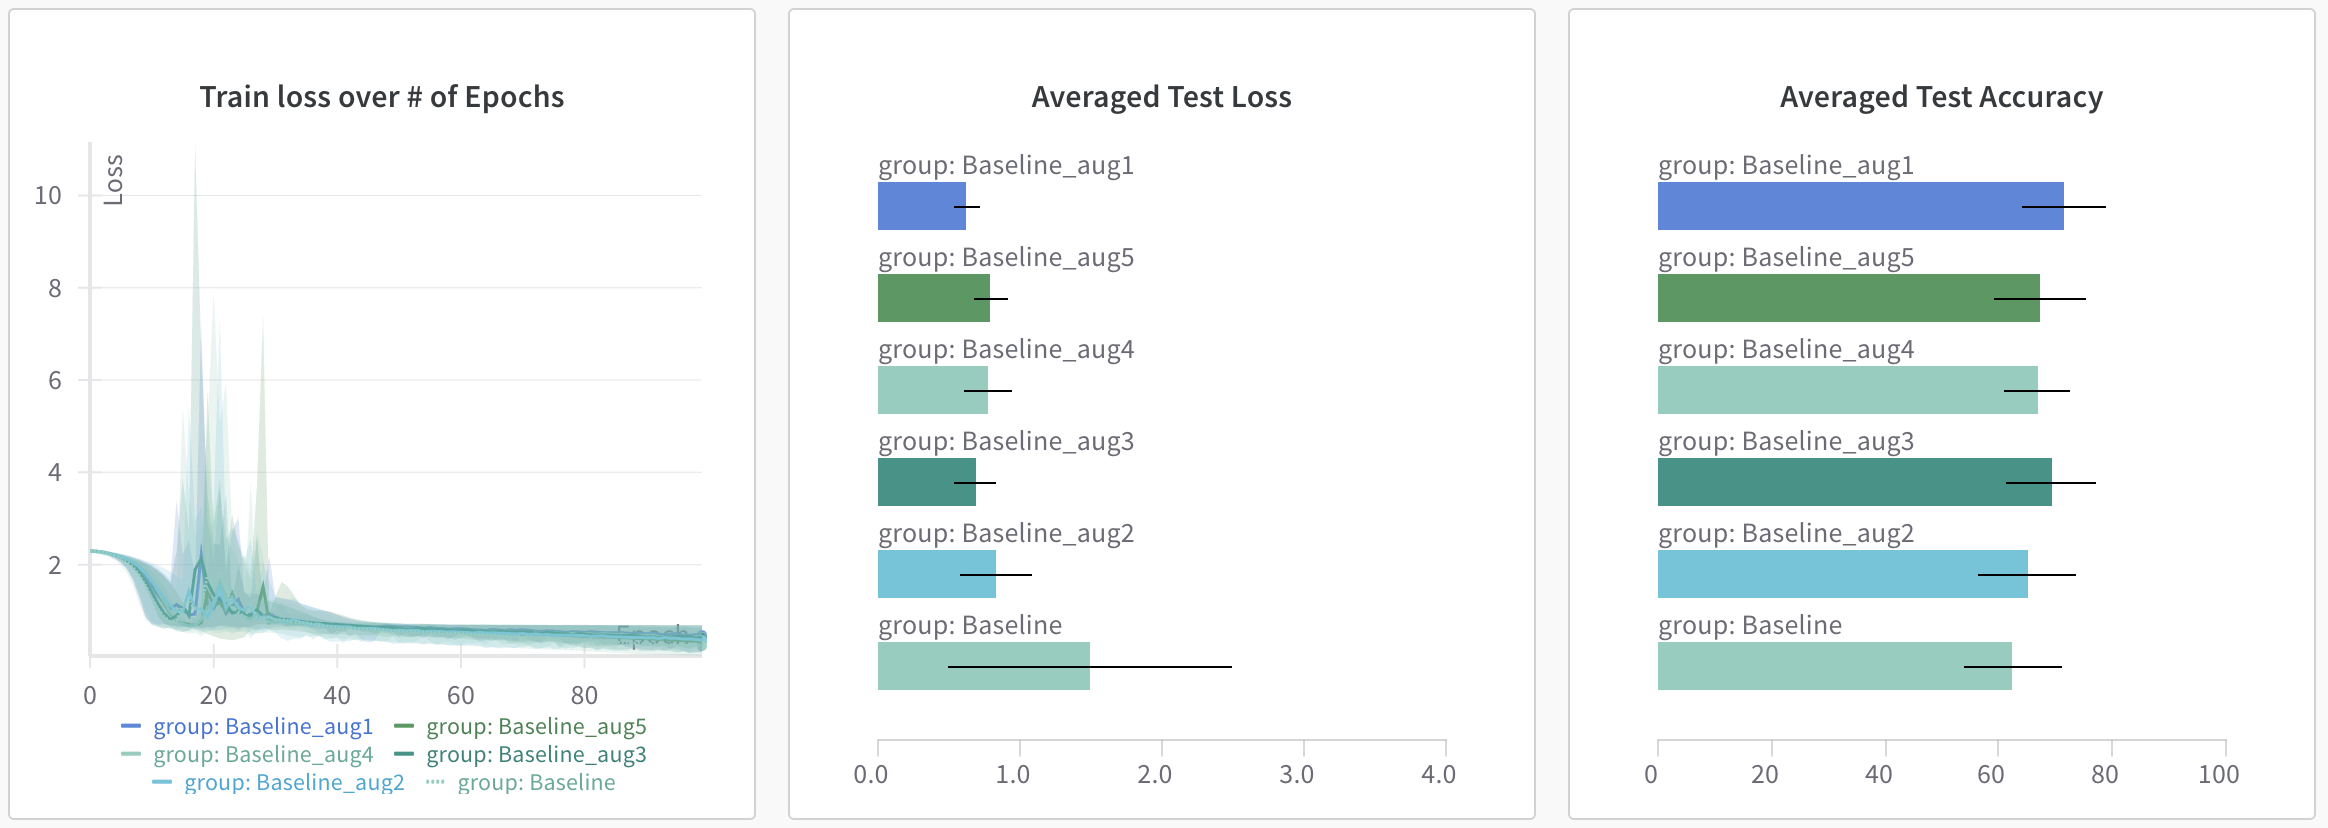

One can see that any techniques, whatever it is, outperforms the baseline. It emphasizes the importance of data augmentation and the benefits it brings. Regarding the results, **augmentation 1 seems to be the most promising one**. This is the one we choose.

## Optimized Baseline
From now on, all the parameters were evaluated individually. It is time to combine them to see if we outperform the baseline.
The final optimized configurations is :


- "epochs": 100,
- "batch_size": 32,
- "lr": 0.01,
- "momentum": 0.8,
- "weight_decay": 0.001,
- "model": "Baseline_wide",
- "data_augmentation": 1   # zero means no augmentation


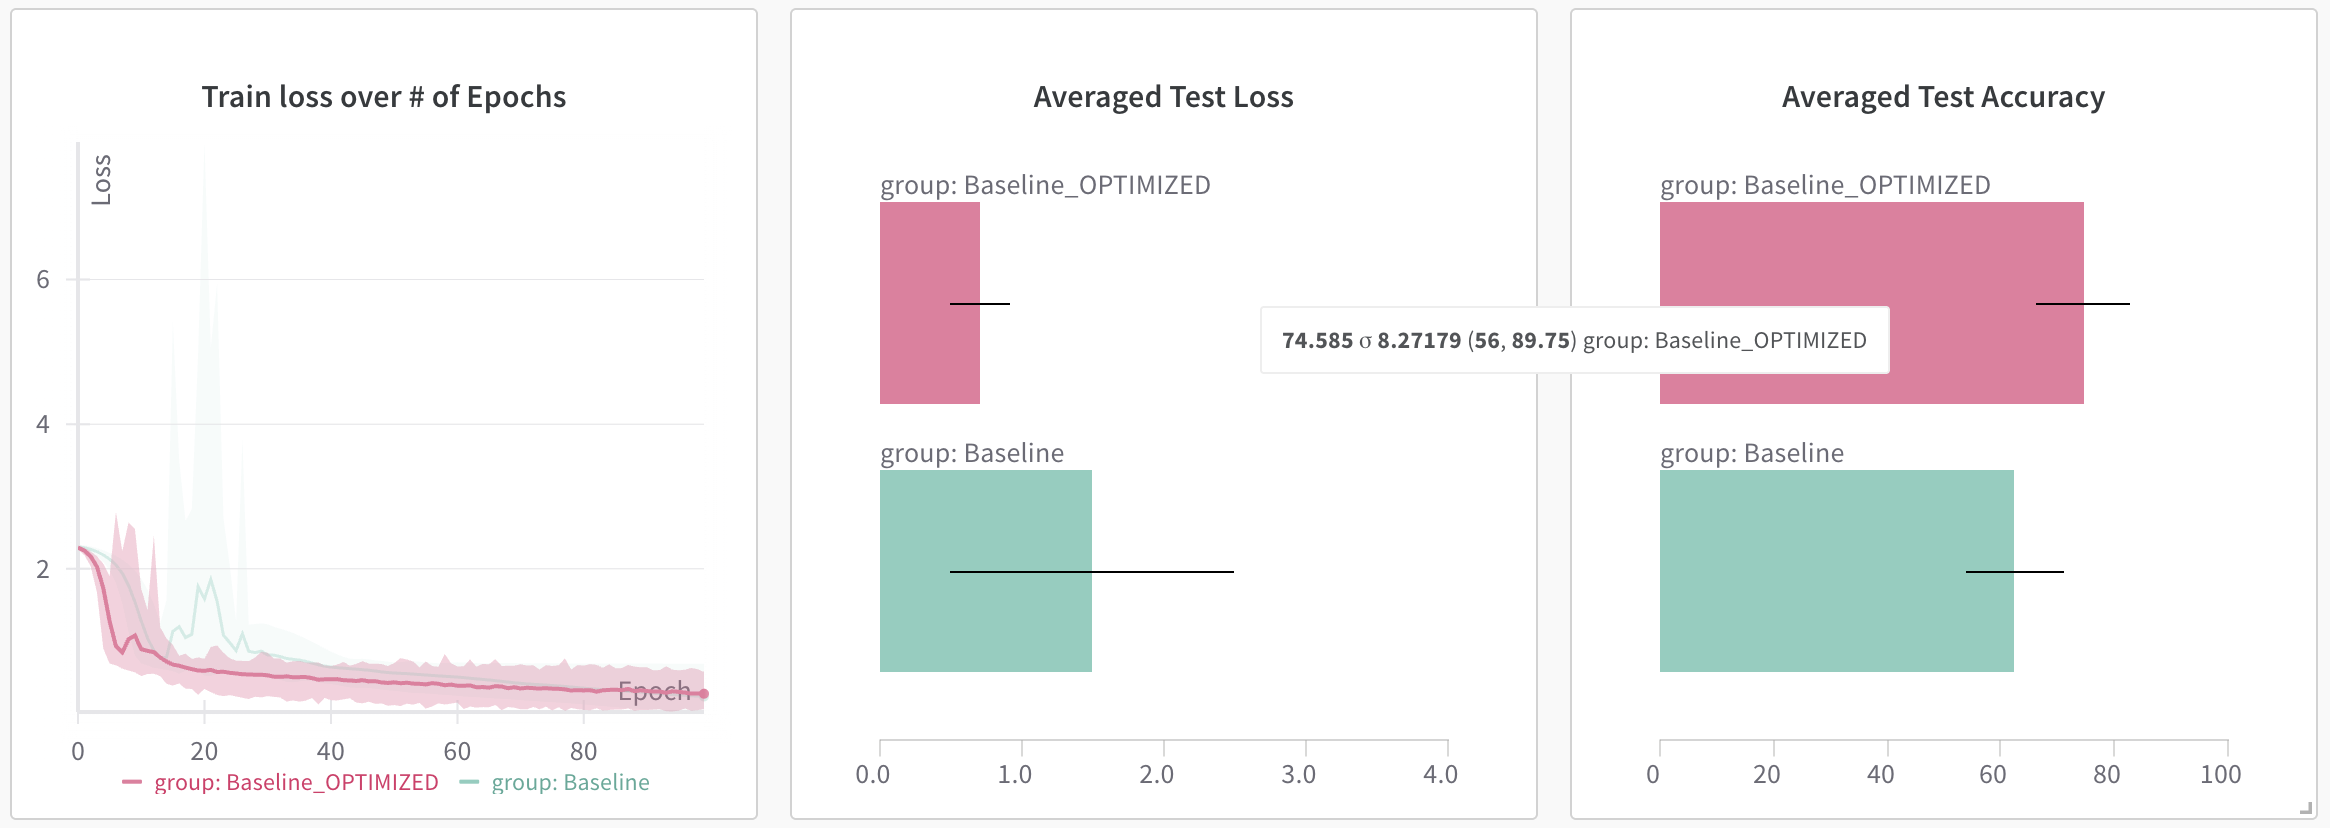

The results are way higher ! **The test loss is of 0.7 for the optimized against 1.5 for the baseline. For the test accuracy, The optimized versions reaches a mean of 74.6% and a std of 8.3 against 62.4 with a std of 8.6 for the baseline.** It is around twelve points higher. These improvements suggests that the diversified augmentation techniques and hparams tuning allow the model to learn more robust features, which in turn improves its generalization ability in a few-shot scenario while slightly reducing the variability in performance.

To ensure correct results, the optimized configuration has been run on 50 seeds.

## Regularization
In our few-shot scenario, regularization might be very efficient or useful. We tried different techniques and combination below such as adding BatchNorm, GroupNorm and Dropout.

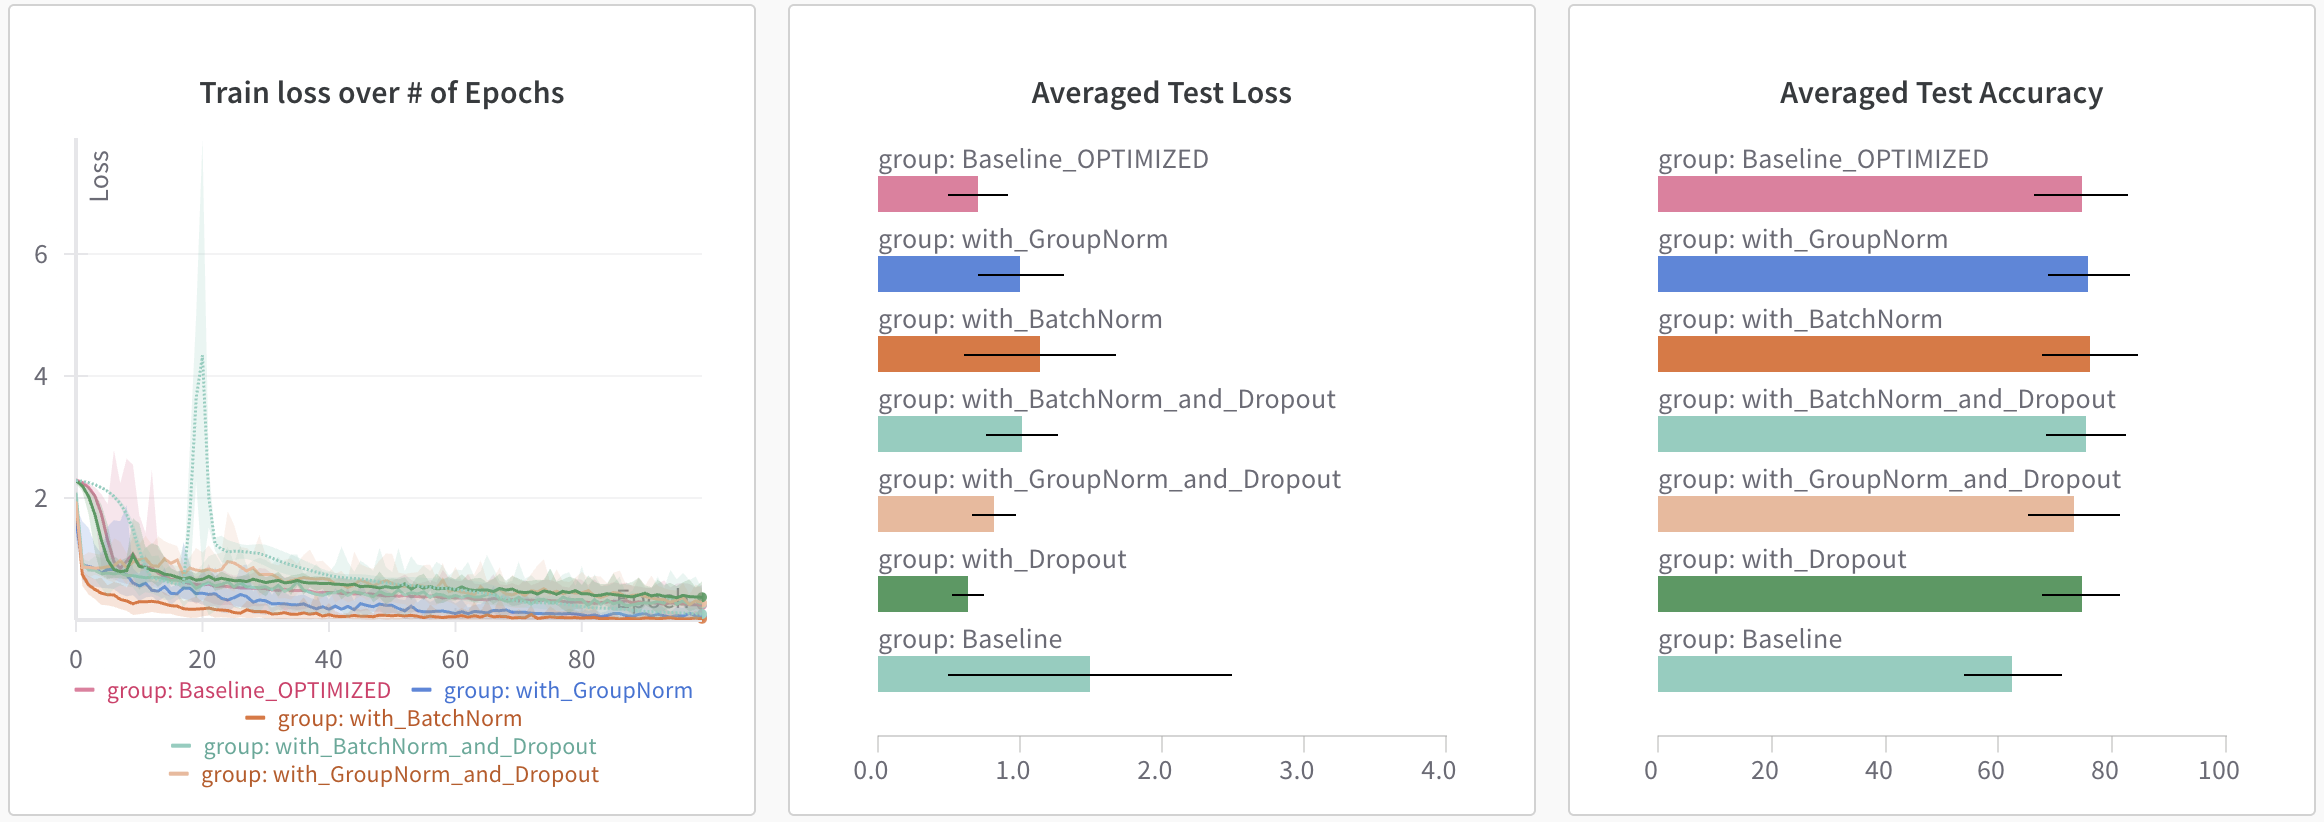

The results demonstrate that adding regularization can help the model to generalize. BatchNorm and GroupNorm alone yields better results, however, the loss on the train set is very close to 0. When using dropout, this loss remain decent. To make sure we don't overfit, **we'll use the BatchNorm with Dropout.**

## Dropout Probability
We now need to find the optimal probability of drop for the dropout layers. The values tested are : {0.1, 0.2, 0.3, 0.4, 0.6}.

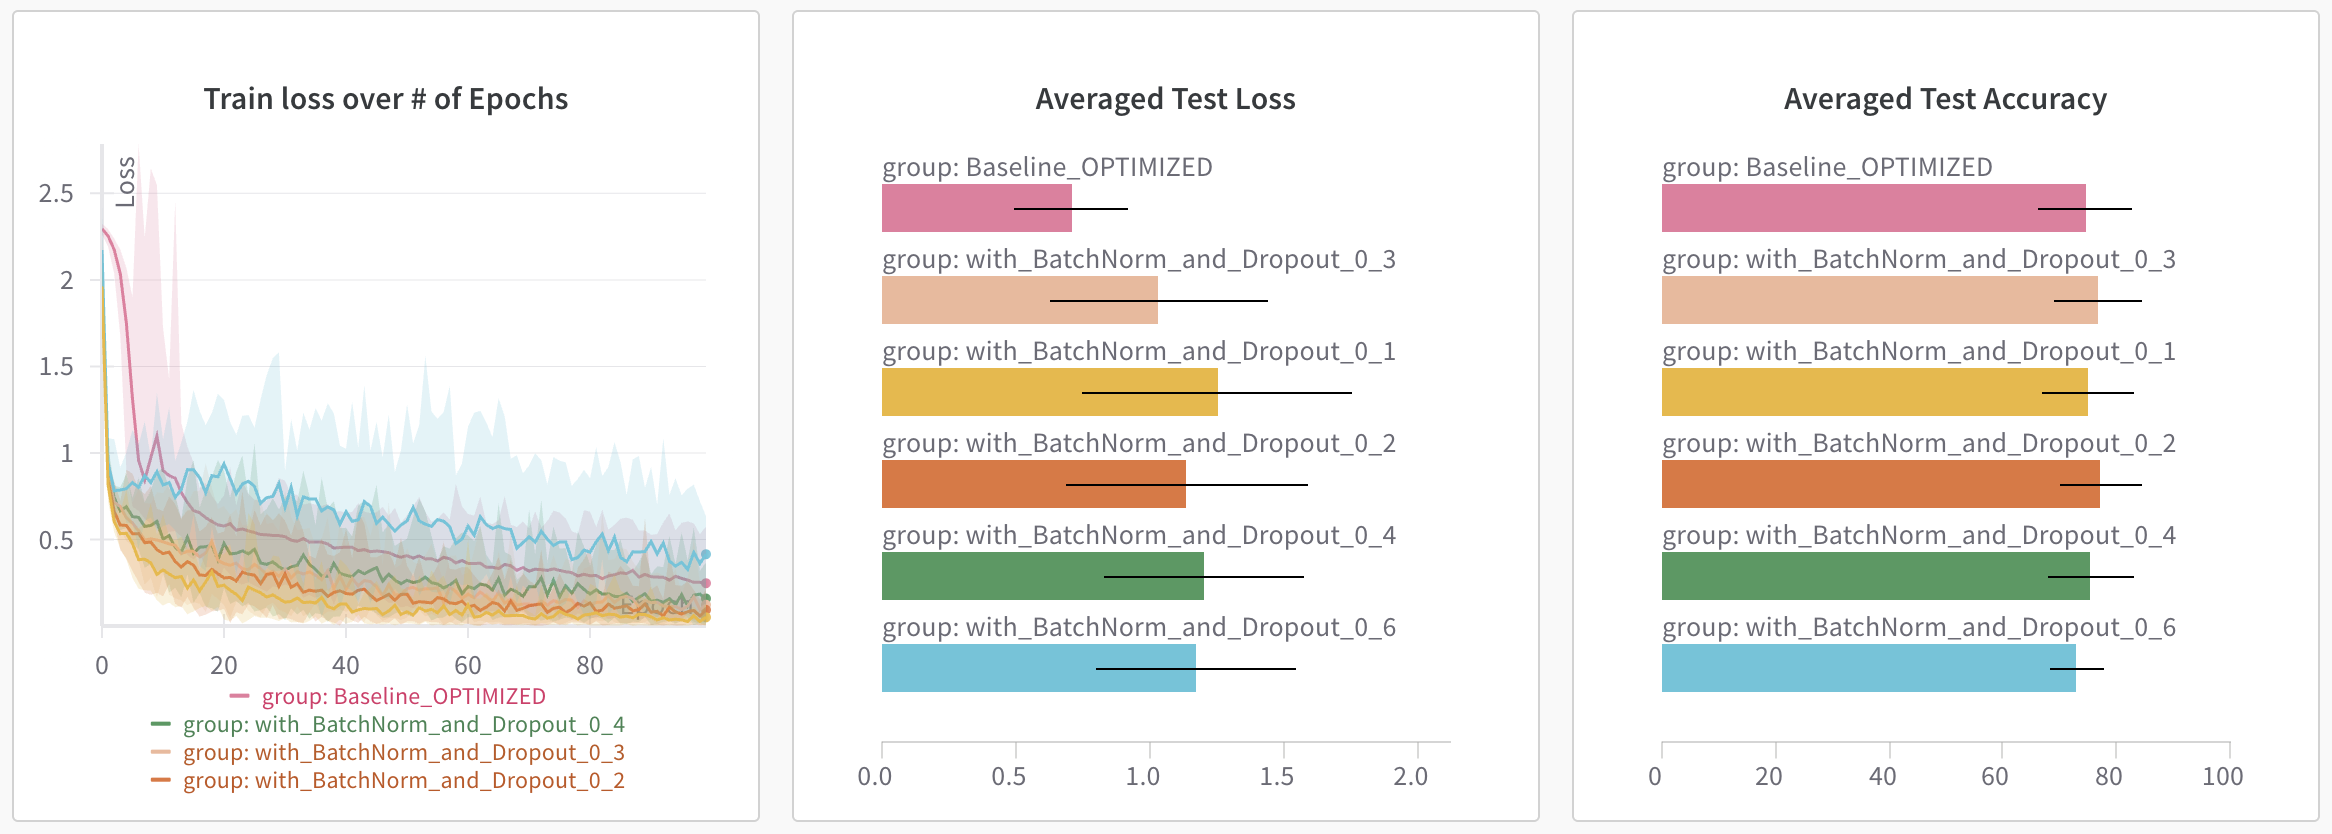

**The best probability p seems to be 0.2.**

## Optimized & Regularized baseline
Combining this information, we run the model on 50 different seeds to confidently assess performance and see if there are any improvements.

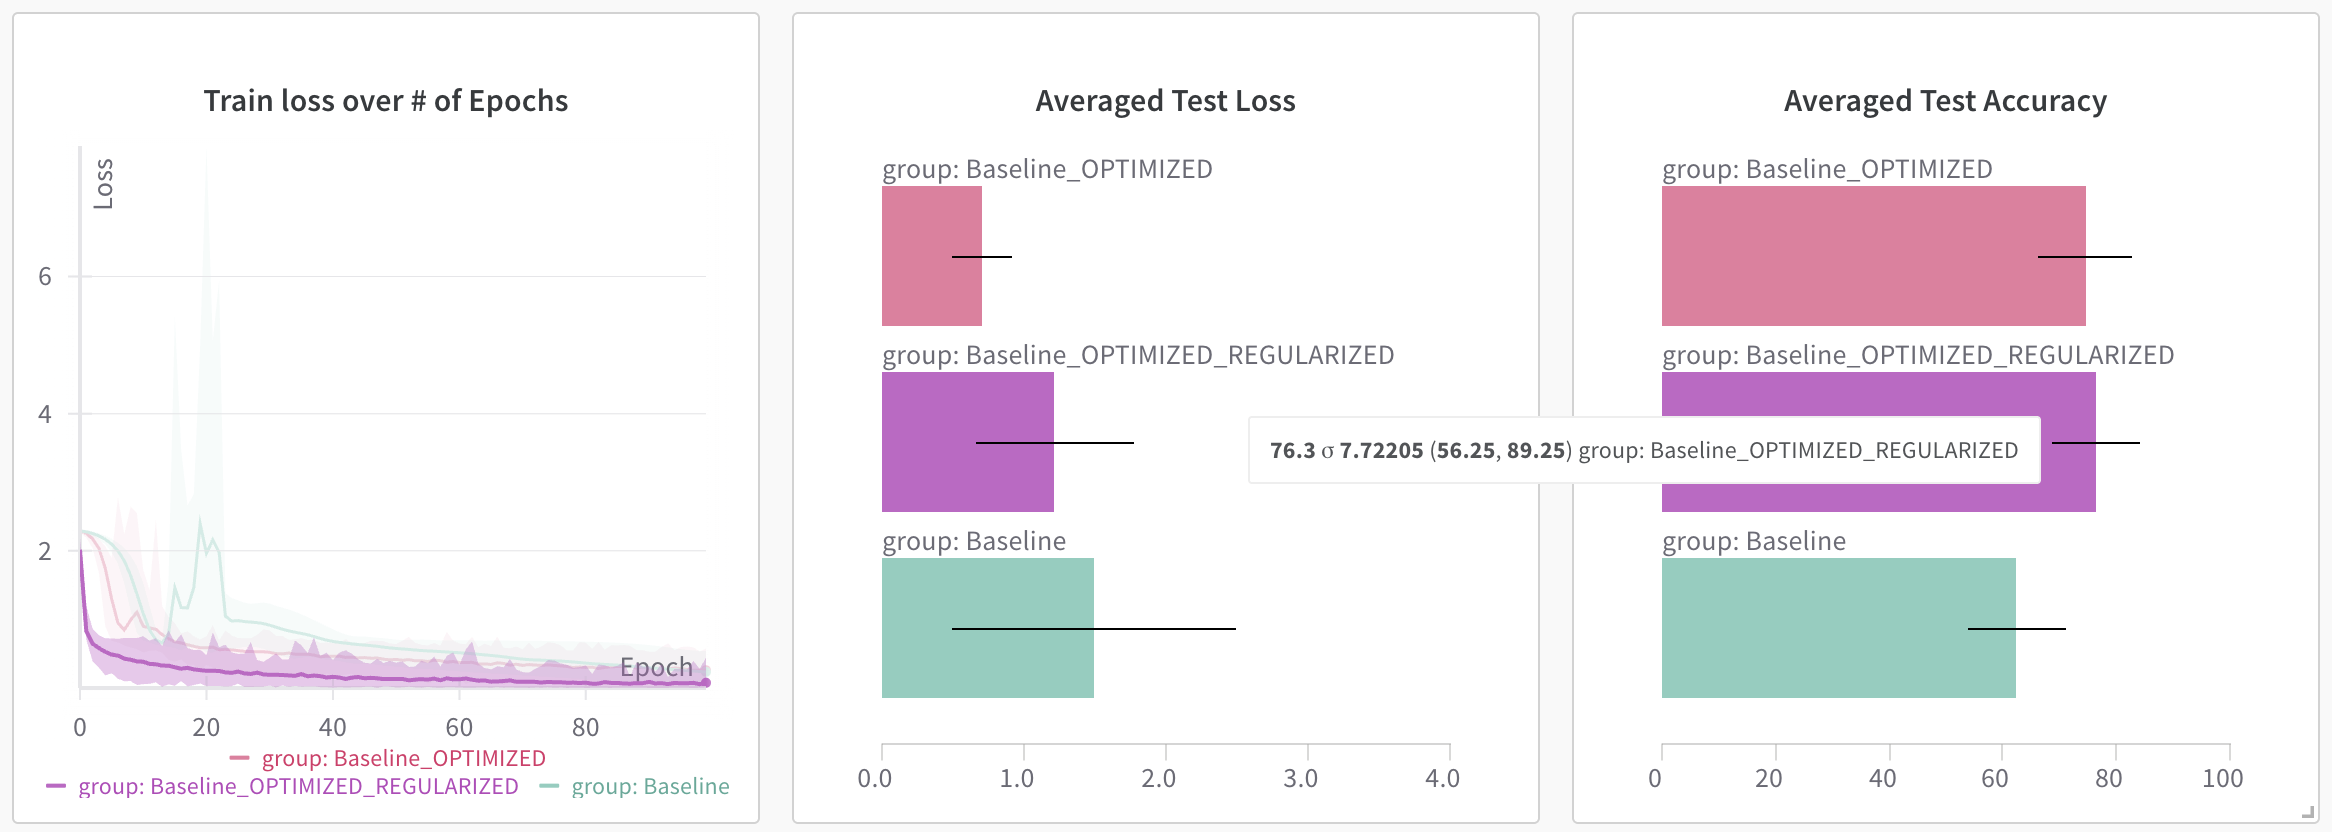

Again, the results have improved! **The new mean accuracy is now 76.3% (std: 7.7)**

# Challenge 2
Now the objective is to leverage in-depth external data and pre-trained models to improve accuracy.

In [ ]:
!pip install wandb -Uq

In [ ]:
import wandb
wandb.login(key="") # Key hidden for privacy

In [ ]:
import pprint

# FIRST RANDOM EXPLORATION

# Search method
sweep_config = {
    'method': 'random',
    'name': "ResNet18_finetune_sweep"
}

# Objective
metric = {
    'name': 'val_accuracy',
    'goal': 'maximize'
}
sweep_config['metric'] = metric

# Parameters
parameters_dict = {
    'seed': {
        'values': [1,2,3,4,5]
      },
    'lr': {
        'values': [0.001, 0.0005, 0.0001]
      },
    'batch_size': {
        'values': [16, 32, 64]
      },
    'freeze_layers': {
        'values': [0, 1, 2, 3]
      },
    'momentum': {
        'values': [0.8, 0.9, 0.99]
      },
    'weight_decay': {
        'values': [0.0001, 0.0005, 0.001]
      },
    'weight_decay': {
        'values': [0.0001, 0.0005, 0.001]
      },
    'epochs': {
        'values': [10, 25, 50, 100]
      }
}
sweep_config['parameters'] = parameters_dict

parameters_dict.update({
    'data_augmentation': {
        'value': 1}
    })

pprint.pprint(sweep_config)

{'method': 'random',
 'metric': {'goal': 'maximize', 'name': 'val_accuracy'},
 'name': 'ResNet18_finetune_sweep',
 'parameters': {'batch_size': {'values': [16, 32, 64]},
                'data_augmentation': {'value': 1},
                'epochs': {'values': [10, 25, 50, 100]},
                'freeze_layers': {'values': [0, 1, 2, 3]},
                'lr': {'values': [0.001, 0.0005, 0.0001]},
                'momentum': {'values': [0.8, 0.9, 0.99]},
                'seed': {'values': [1, 2, 3, 4, 5]},
                'weight_decay': {'values': [0.0001, 0.0005, 0.001]}}}


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Subset, DataLoader
from torchvision import datasets, transforms, models
import numpy as np
import wandb
from numpy.random import RandomState

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Build train and validation loaders for few-shot CIFAR-10
def build_dataset(batch_size, data_augmentation, seed):
    normalize = transforms.Normalize((0.4914, 0.4822, 0.4465),
                                     (0.247, 0.243, 0.261))
    transform_val = transforms.Compose([transforms.ToTensor(), normalize])
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        normalize
    ])
    transform_dict = {
        0: transforms.Compose([transforms.ToTensor(), normalize]),
        1: transform_train
    }
    cifar_train_full = datasets.CIFAR10(root='.', train=True,
                                        transform=transform_dict[data_augmentation],
                                        download=True)
    cifar_val_full   = datasets.CIFAR10(root='.', train=True,
                                        transform=transform_val,
                                        download=True)
    prng = RandomState(seed)
    perm = prng.permutation(1000)
    classes = prng.permutation(10)
    # select 2 random classes
    train_idx = np.concatenate([
        np.where(np.array(cifar_train_full.targets) == c)[0][perm[:25]]
        for c in classes[:2]
    ])
    val_idx = np.concatenate([
        np.where(np.array(cifar_val_full.targets) == c)[0][perm[25:225]]
        for c in classes[:2]
    ])
    train_loader = DataLoader(Subset(cifar_train_full, train_idx),
                              batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(Subset(cifar_val_full,   val_idx),
                              batch_size=batch_size, shuffle=False)
    return train_loader, val_loader

# Build ResNet18 with dynamic freezing
def build_network(freeze_layers):
    model = models.resnet18(pretrained=True)
    # always freeze conv1 & bn1
    for p in model.conv1.parameters(): p.requires_grad = False
    for p in model.bn1.parameters():  p.requires_grad = False
    # freeze first N residual blocks
    blocks = [model.layer1, model.layer2, model.layer3]
    for idx, block in enumerate(blocks, start=1):
        freeze = idx <= freeze_layers
        for p in block.parameters(): p.requires_grad = not freeze
    # always unfreeze layer4 and classifier
    for p in model.layer4.parameters(): p.requires_grad = True
    model.fc = nn.Linear(model.fc.in_features, 10)
    for p in model.fc.parameters(): p.requires_grad = True
    return model.to(device)

# Build SGD optimizer
def build_optimizer(model, lr, momentum, weight_decay):
    params = filter(lambda p: p.requires_grad, model.parameters())
    return optim.SGD(params, lr=lr, momentum=momentum, weight_decay=weight_decay)

# Single epoch training
def train_epoch(model, device, loader, optimizer):
    model.train()
    total_loss = 0.0
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.cross_entropy(output, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        wandb.log({"batch_loss": loss.item()})
    return total_loss / len(loader)

# Evaluation on validation set
def evaluate(model, device, loader):
    model.eval()
    test_loss = 0.0
    correct = 0
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.cross_entropy(output, target, reduction='sum').item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
    test_loss /= len(loader.dataset)
    accuracy = 100. * correct / len(loader.dataset)
    return test_loss, accuracy

In [ ]:
# Main train function for sweep
def train(config=None):
    with wandb.init(config=config):
        cfg = wandb.config
        # reproducibility
        torch.manual_seed(cfg.seed)
        np.random.seed(cfg.seed)
        # prepare data
        train_loader, val_loader = build_dataset(
            cfg.batch_size, cfg.data_augmentation, cfg.seed
        )
        # build model and optimizer
        model = build_network(cfg.freeze_layers)
        optimizer = build_optimizer(
            model, cfg.lr, cfg.momentum, cfg.weight_decay
        )
        # training loop
        for epoch in range(cfg.epochs):
            avg_loss = train_epoch(model, device, train_loader, optimizer)
            val_loss, val_acc = evaluate(model, device, val_loader)
            # log metrics
            wandb.log({
                "train_loss": avg_loss,
                "val_loss": val_loss,
                "val_accuracy": val_acc,
                "epoch": epoch
            })

In [ ]:
sweep_id = wandb.sweep(sweep_config, project="Challenge2_DL_v1")

In [ ]:
wandb.agent(sweep_id, train, count=100)

### Different Pre-Trained Models
In this section we have fixed some hparams after the random search. The goal now is to test different pretrained architectures and see the effect of freezing. All that on various seeds

In [ ]:
import pprint

# GRID SEARCH PRETRAINED

# Search method
sweep_config = {
    'method': 'grid',
    'name': "PreTrained_finetune_sweep"
}

# Objective
metric = {
    'name': 'val_accuracy',
    'goal': 'maximize'
}
sweep_config['metric'] = metric

# Parameters
parameters_dict = {
    'seed': {
        'values': [1,2,3,4,5]
      },
    'lr': {
        'values': [0.001, 0.0001]
      },
    'batch_size': {
        'values': [32]
      },
    'model_name': {
        'values': ["resnet18", "resnet34", "resnet50", "resnet101"]
      },
    'freeze_layers': {
        'values': [0, 1, 2, 3, 4]
      },
    'momentum': {
        'values': [0.9]
      },
    'weight_decay': {
        'values': [0.0005]
      },
    'epochs': {
        'values': [50]
      }
}
sweep_config['parameters'] = parameters_dict

parameters_dict.update({
    'data_augmentation': {
        'value': 1}
    })

pprint.pprint(sweep_config)

{'method': 'grid',
 'metric': {'goal': 'maximize', 'name': 'val_accuracy'},
 'name': 'PreTrained_finetune_sweep',
 'parameters': {'batch_size': {'values': [32]},
                'data_augmentation': {'value': 1},
                'epochs': {'values': [50]},
                'freeze_layers': {'values': [0, 1, 2, 3, 4]},
                'lr': {'values': [0.001, 0.0001]},
                'model_name': {'values': ['resnet18',
                                          'resnet34',
                                          'resnet50',
                                          'resnet101']},
                'momentum': {'values': [0.9]},
                'seed': {'values': [1, 2, 3, 4, 5]},
                'weight_decay': {'values': [0.0005]}}}


We need to do some slight modification to ensure all the models are instantiated and tried in the right configuration.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Subset, DataLoader
from torchvision import datasets, transforms, models
import numpy as np
import wandb
from numpy.random import RandomState

# Choose device
if torch.backends.mps.is_available():
    print("Device used is MPS - Apple")
    device = torch.device("mps")

elif torch.cuda.is_available():
    print("Device used is CUDA - Nvidia")
    device = torch.device("cuda")

else:
    print("Device used is CPU")
    device = torch.device("cpu")

# Build train and validation loaders for few-shot CIFAR-10
def build_dataset(batch_size, data_augmentation, seed):
    normalize = transforms.Normalize((0.4914, 0.4822, 0.4465),
                                     (0.247, 0.243, 0.261))
    transform_val = transforms.Compose([transforms.ToTensor(), normalize])
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        normalize
    ])
    transform_dict = {
        0: transforms.Compose([transforms.ToTensor(), normalize]),
        1: transform_train
    }
    cifar_train_full = datasets.CIFAR10(root='.', train=True,
                                        transform=transform_dict[data_augmentation],
                                        download=True)
    cifar_val_full   = datasets.CIFAR10(root='.', train=True,
                                        transform=transform_val,
                                        download=True)
    prng = RandomState(seed)
    perm = prng.permutation(1000)
    classes = prng.permutation(10)
    # select 2 random classes
    train_idx = np.concatenate([
        np.where(np.array(cifar_train_full.targets) == c)[0][perm[:25]]
        for c in classes[:2]
    ])
    val_idx = np.concatenate([
        np.where(np.array(cifar_val_full.targets) == c)[0][perm[25:225]]
        for c in classes[:2]
    ])
    train_loader = DataLoader(Subset(cifar_train_full, train_idx),
                              batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(Subset(cifar_val_full,   val_idx),
                              batch_size=batch_size, shuffle=False)
    return train_loader, val_loader

# Build ResNet18 with dynamic freezing
def build_network(model_name, freeze_layers):
    # 1) Choix du backbone
    if model_name == "resnet18":
        model = models.resnet18(pretrained=True)
    elif model_name == "resnet34":
        model = models.resnet34(pretrained=True)
    elif model_name == "resnet50":
        model = models.resnet50(pretrained=True)
    elif model_name == "resnet101":
        model = models.resnet101(pretrained=True)
    else:
        raise ValueError(f"Not known model {model_name}")

    # always freeze conv1 & bn1
    for p in model.conv1.parameters(): p.requires_grad = False
    for p in model.bn1.parameters():  p.requires_grad = False
    # freeze first N residual blocks
    blocks = [model.layer1, model.layer2, model.layer3, model.layer4]
    for idx, block in enumerate(blocks, start=1):
        freeze = idx <= freeze_layers
        for p in block.parameters(): p.requires_grad = not freeze
    # always unfreeze classifier
    model.fc = nn.Linear(model.fc.in_features, 10)
    for p in model.fc.parameters(): p.requires_grad = True
    return model.to(device)

# Build SGD optimizer
def build_optimizer(model, lr, momentum, weight_decay):
    params = filter(lambda p: p.requires_grad, model.parameters())
    return optim.SGD(params, lr=lr, momentum=momentum, weight_decay=weight_decay)

# Single epoch training
def train_epoch(model, device, loader, optimizer):
    model.train()
    total_loss = 0.0
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.cross_entropy(output, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        wandb.log({"batch_loss": loss.item()})
    return total_loss / len(loader)

# Evaluation on validation set
def evaluate(model, device, loader):
    model.eval()
    test_loss = 0.0
    correct = 0
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.cross_entropy(output, target, reduction='sum').item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
    test_loss /= len(loader.dataset)
    accuracy = 100. * correct / len(loader.dataset)
    return test_loss, accuracy

Device used is MPS - Apple


In [ ]:
# Main train function for sweep
def train_pretrained_comparison(config=None):
    with wandb.init(config=config):
        cfg = wandb.config
        # reproducibility
        torch.manual_seed(cfg.seed)
        np.random.seed(cfg.seed)
        # prepare data
        train_loader, val_loader = build_dataset(
            cfg.batch_size, cfg.data_augmentation, cfg.seed
        )
        # build model and optimizer
        model = build_network(cfg.model_name, cfg.freeze_layers)
        optimizer = build_optimizer(
            model, cfg.lr, cfg.momentum, cfg.weight_decay
        )
        # training loop
        for epoch in range(cfg.epochs):
            avg_loss = train_epoch(model, device, train_loader, optimizer)
            val_loss, val_acc = evaluate(model, device, val_loader)
            # log metrics
            wandb.log({
                "train_loss": avg_loss,
                "val_loss": val_loss,
                "val_accuracy": val_acc,
                "epoch": epoch
            })

In [ ]:
sweep_id = wandb.sweep(sweep_config, project="Challenge2_DL_v1", entity='s_c92666-concordia-university')

Create sweep with ID: sluovvou
Sweep URL: https://wandb.ai/s_c92666-concordia-university/Challenge2_DL_v1/sweeps/sluovvou


In [ ]:
wandb.agent(sweep_id, train_pretrained_comparison, count=200)

Try the actual best config

In [ ]:
import pprint

# GRID SEARCH PRETRAINED

# Search method
sweep_config = {
    'method': 'grid',
    'name': "Verify_best_finetune_sweep"
}

# Objective
metric = {
    'name': 'val_accuracy',
    'goal': 'maximize'
}
sweep_config['metric'] = metric

# Parameters
parameters_dict = {
    'seed': {
        'values': [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30]
      },
    'lr': {
        'values': [0.001]
      },
    'batch_size': {
        'values': [32]
      },
    'model_name': {
        'values': ["resnet18", "resnet50"]
      },
    'freeze_layers': {
        'values': [1]
      },
    'momentum': {
        'values': [0.9]
      },
    'weight_decay': {
        'values': [0.0005]
      },
    'epochs': {
        'values': [50]
      }
}
sweep_config['parameters'] = parameters_dict

parameters_dict.update({
    'data_augmentation': {
        'value': 1}
    })

pprint.pprint(sweep_config)

{'method': 'grid',
 'metric': {'goal': 'maximize', 'name': 'val_accuracy'},
 'name': 'Verify_best_finetune_sweep',
 'parameters': {'batch_size': {'values': [32]},
                'data_augmentation': {'value': 1},
                'epochs': {'values': [50]},
                'freeze_layers': {'values': [1]},
                'lr': {'values': [0.001]},
                'model_name': {'values': ['resnet18', 'resnet50']},
                'momentum': {'values': [0.9]},
                'seed': {'values': [1,
                                    2,
                                    3,
                                    4,
                                    5,
                                    6,
                                    7,
                                    8,
                                    9,
                                    10,
                                    11,
                                    12,
                                    13,
                       

In [ ]:
sweep_id = wandb.sweep(sweep_config, project="Challenge2_DL_v1", entity='s_c92666-concordia-university')

Create sweep with ID: 0mobzyvj
Sweep URL: https://wandb.ai/s_c92666-concordia-university/Challenge2_DL_v1/sweeps/0mobzyvj


In [ ]:
wandb.agent(sweep_id, train_pretrained_comparison, count=60)

wandb: Agent Starting Run: fg14kiea with config:
wandb: 	batch_size: 32
wandb: 	data_augmentation: 1
wandb: 	epochs: 50
wandb: 	freeze_layers: 1
wandb: 	lr: 0.001
wandb: 	model_name: resnet18
wandb: 	momentum: 0.9
wandb: 	seed: 1
wandb: 	weight_decay: 0.0005


/opt/miniconda3/envs/DL_project_env/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/miniconda3/envs/DL_project_env/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
wandb: ERROR The nbformat package was not found. It is required to save notebook history.


batch_loss,█▇▃▂▂▂▂▃▂▂▁▁▁▂▁▁▂▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁
epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
train_loss,█▆▄▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▂▁▂▁▁▂▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁
val_accuracy,▁▅▆▇▇▇██▇█▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇██▇▇▇▇▇▇████
val_loss,█▆▃▂▂▁▁▁▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▂▃▃▂▂▃▃▃
batch_loss,0.11346
epoch,49
train_loss,0.06852
val_accuracy,68.25
val_loss,1.03969


wandb: Agent Starting Run: p5mdu00o with config:
wandb: 	batch_size: 32
wandb: 	data_augmentation: 1
wandb: 	epochs: 50
wandb: 	freeze_layers: 1
wandb: 	lr: 0.001
wandb: 	model_name: resnet18
wandb: 	momentum: 0.9
wandb: 	seed: 2
wandb: 	weight_decay: 0.0005


/opt/miniconda3/envs/DL_project_env/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/miniconda3/envs/DL_project_env/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
wandb: ERROR The nbformat package was not found. It is required to save notebook history.


...

/opt/miniconda3/envs/DL_project_env/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/miniconda3/envs/DL_project_env/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
wandb: ERROR The nbformat package was not found. It is required to save notebook history.


batch_loss,█▇▆▄▃▂▂▂▂▂▂▂▂▁▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
train_loss,█▆▅▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_accuracy,▁▄▅▅▅▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇█▇▇▇▇███████
val_loss,█▅▃▃▂▂▂▂▂▁▁▁▁▁▁▂▂▂▂▂▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁
batch_loss,0.03043
epoch,49
train_loss,0.01874
val_accuracy,84.75
val_loss,0.44365


wandb: Agent Starting Run: 0dqk0x58 with config:
wandb: 	batch_size: 32
wandb: 	data_augmentation: 1
wandb: 	epochs: 50
wandb: 	freeze_layers: 1
wandb: 	lr: 0.001
wandb: 	model_name: resnet50
wandb: 	momentum: 0.9
wandb: 	seed: 30
wandb: 	weight_decay: 0.0005


/opt/miniconda3/envs/DL_project_env/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/miniconda3/envs/DL_project_env/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
wandb: ERROR The nbformat package was not found. It is required to save notebook history.


batch_loss,█▇▄▄▃▃▃▂▃▂▂▂▂▂▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
train_loss,█▆▄▃▃▂▃▂▂▂▂▂▂▂▂▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_accuracy,▁▅▆▆▇▇▇▇▇▇▇▇▇▇▇▇████████████████████████
val_loss,█▅▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂
batch_loss,0.0031
epoch,49
train_loss,0.00634
val_accuracy,81.5
val_loss,0.65448


# MAML Approach

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Subset, DataLoader
from torchvision import datasets, transforms, models
import numpy as np
import wandb
from copy import deepcopy

# Device
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

# Build a ResNet-based model for 2-way classification
class ResNetBackbone(nn.Module):
    def __init__(self, backbone_name='resnet18'):
        super().__init__()
        # load pretrained backbone
        if backbone_name == 'resnet18':
            self.model = models.resnet18(pretrained=True)
        elif backbone_name == 'resnet34':
            self.model = models.resnet34(pretrained=True)
        elif backbone_name == 'resnet50':
            self.model = models.resnet50(pretrained=True)
        else:
            raise ValueError(f"Unsupported backbone {backbone_name}")
        # remove original fc
        in_feat = self.model.fc.in_features
        self.model.fc = nn.Identity()
        # new head for 2 classes
        self.classifier = nn.Linear(in_feat, 2)

    def forward(self, x):
        feat = self.model(x)
        return self.classifier(feat)

# Sample one MAML task (2-way few-shot)
def sample_task(dataset, classes, n_support, n_query, seed=None):
    rng = np.random.RandomState(seed)
    c1, c2 = rng.choice(classes, 2, replace=False)
    idx = np.array(dataset.targets)
    support_idx, query_idx = [], []
    for c in (c1, c2):
        c_idx = np.where(idx==c)[0]
        perm = rng.permutation(c_idx)
        support_idx.extend(perm[:n_support])
        query_idx.extend(perm[n_support:n_support+n_query])
    support_loader = DataLoader(Subset(dataset, support_idx), batch_size=len(support_idx), shuffle=False)
    query_loader   = DataLoader(Subset(dataset, query_idx),   batch_size=len(query_idx),   shuffle=False)
    return support_loader, query_loader, [c1, c2]

# MAML meta-training

def train_maml(config=None):
    with wandb.init(config=config):
        cfg = wandb.config
        torch.manual_seed(cfg.seed)
        np.random.seed(cfg.seed)
        # data + transform
        normalize = transforms.Normalize((0.4914,0.4822,0.4465),(0.247,0.243,0.261))
        transform = transforms.Compose([transforms.ToTensor(), normalize])
        cifar = datasets.CIFAR10('.', train=True, transform=transform, download=True)
        classes = list(range(10))
        # meta-model
        meta_model = ResNetBackbone(cfg.backbone).to(device)
        meta_opt   = optim.Adam(meta_model.parameters(), lr=cfg.meta_lr)
        # meta-training loop
        for epoch in range(cfg.meta_epochs):
            meta_opt.zero_grad()
            total_loss = 0.0
            total_acc  = 0.0
            for t in range(cfg.tasks_per_epoch):
                # sample task
                sup, qry, two = sample_task(
                    cifar, classes, cfg.n_support, cfg.n_query,
                    seed=cfg.seed + epoch*cfg.tasks_per_epoch + t)
                # clone for inner loop
                fast_model = deepcopy(meta_model)
                fast_opt   = optim.SGD(fast_model.parameters(), lr=cfg.inner_lr)
                # inner adaptation
                fast_model.train()
                for _ in range(cfg.inner_steps):
                    for x_s, y_s in sup:
                        x_s, y_s = x_s.to(device), y_s.to(device)
                        y_s = torch.tensor([0 if y==two[0] else 1 for y in y_s], device=device)
                        logits = fast_model(x_s)
                        loss = F.cross_entropy(logits, y_s)
                        fast_opt.zero_grad(); loss.backward(); fast_opt.step()
                # query evaluation
                fast_model.eval()
                for x_q, y_q in qry:
                    x_q, y_q = x_q.to(device), y_q.to(device)
                    y_q = torch.tensor([0 if y==two[0] else 1 for y in y_q], device=device)
                    logits_q = fast_model(x_q)
                    lq = F.cross_entropy(logits_q, y_q)
                    total_loss += lq
                    total_acc  += (logits_q.argmax(1)==y_q).float().mean()
            # meta update
            total_loss /= cfg.tasks_per_epoch
            total_acc  /= cfg.tasks_per_epoch
            total_loss.backward()
            meta_opt.step()
            wandb.log({
                'meta_epoch': epoch,
                'meta_loss': total_loss.item(),
                'meta_accuracy': total_acc.item()
            })

In [ ]:
sweep_config = {
        'name': 'MAML_sweep',
        'method':'grid',
        'metric':{'name':'meta_accuracy','goal':'maximize'},
        'parameters':{
            'seed':{'values':[1,2,3]},
            'backbone':{'values':['resnet18', 'resnet50']},
            'meta_lr':{'values':[1e-3,1e-4]},
            'inner_lr':{'values':[0.1,0.01]},
            'inner_steps':{'values':[5,10]},
            'meta_epochs':{'value':20},
            'tasks_per_epoch':{'value':10},
            'n_support':{'value':25},
            'n_query':{'value':25}
        }
    }

In [ ]:
sweep_id = wandb.sweep(sweep_config, project="Challenge2_DL_v1", entity="s_c92666-concordia-university")


wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


Create sweep with ID: ejn20ebt
Sweep URL: https://wandb.ai/s_c92666-concordia-university/Challenge2_DL_v1/sweeps/ejn20ebt


In [ ]:
wandb.agent(sweep_id, train_maml, count=48)

wandb: Agent Starting Run: ft0l4t8g with config:
wandb: 	backbone: resnet18
wandb: 	inner_lr: 0.1
wandb: 	inner_steps: 5
wandb: 	meta_epochs: 20
wandb: 	meta_lr: 0.001
wandb: 	n_query: 25
wandb: 	n_support: 25
wandb: 	seed: 1
wandb: 	tasks_per_epoch: 10
wandb: Currently logged in as: s_c92666 (s_c92666-concordia-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/opt/miniconda3/envs/DL_project_env/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/miniconda3/envs/DL_project_env/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
wandb: ERROR The nbformat package was not found. It is required to save notebook history.


meta_accuracy,▆▄█▂▂▂▆▁▄▂▃▅▁▄▄▃▄▂▃▃
meta_epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
meta_loss,▂▂▂█▂▃▁▆▅▂▃▂▅▂▂▇▄▂█▂
meta_accuracy,0.544
meta_epoch,19
meta_loss,45.26837


wandb: Agent Starting Run: hvf3jz1c with config:
wandb: 	backbone: resnet18
wandb: 	inner_lr: 0.1
wandb: 	inner_steps: 5
wandb: 	meta_epochs: 20
wandb: 	meta_lr: 0.001
wandb: 	n_query: 25
wandb: 	n_support: 25
wandb: 	seed: 2
wandb: 	tasks_per_epoch: 10


/opt/miniconda3/envs/DL_project_env/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/miniconda3/envs/DL_project_env/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
wandb: ERROR The nbformat package was not found. It is required to save notebook history.


...

wandb: Agent Starting Run: 6q3mwrln with config:
wandb: 	backbone: resnet18
wandb: 	inner_lr: 0.01
wandb: 	inner_steps: 10
wandb: 	meta_epochs: 20
wandb: 	meta_lr: 0.0001
wandb: 	n_query: 25
wandb: 	n_support: 25
wandb: 	seed: 2
wandb: 	tasks_per_epoch: 10


/opt/miniconda3/envs/DL_project_env/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/miniconda3/envs/DL_project_env/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
wandb: ERROR The nbformat package was not found. It is required to save notebook history.


meta_accuracy,▃▃█▃▂▅▄▆▆▂▄▃▅▃▅▆▅▄▆▁
meta_epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
meta_loss,▄▆▁▇▇▄▅▄▅█▄▅▅▅▄▃▅▃▄▆
meta_accuracy,0.622
meta_epoch,19
meta_loss,0.61782


wandb: Agent Starting Run: 1an4f2kz with config:
wandb: 	backbone: resnet18
wandb: 	inner_lr: 0.01
wandb: 	inner_steps: 10
wandb: 	meta_epochs: 20
wandb: 	meta_lr: 0.0001
wandb: 	n_query: 25
wandb: 	n_support: 25
wandb: 	seed: 3
wandb: 	tasks_per_epoch: 10


wandb: Ctrl + C detected. Stopping sweep.


# Garbage